# Storage class v2 — from link classes to the dependence metrics

v1 classified links (demand- vs storage-driven) and tested reconstruction. It never tested what the
classification is **for**: the district × district metrics. This notebook connects the two, fixes the v1
tests that failed, and writes every per-sensor result to disk.

| block | question | why it matters for the metrics |
|---|---|---|
| 0 · classes | demand / storage class per link and world; flow-based and state-based | the channel a link carries |
| R · reconstruction | does a demand mixture (R1), demand + hub **state** (R4), the labels (R3) rebuild each link? is a coefficient stable inside its own drift (R2)? | whether the **mixture** metric can describe the link at all |
| S1 · detection | is the world stationary outside the drift? calibrated detection per link and per hub element | whether a client "sees" a drift — the raw material of the interventional metric |
| D1 · interventional | empirical $D[j,k]$ from the target worlds: all links, demand links only, storage de-duplicated | does the stack's **dependence / response** reproduce, and what carries its off-diagonal? |
| D2 · sensitivity | off-diagonal share carried by storage links; effect of re-homing and de-duplication | whether the metric measures coupling or a homing / counting rule |
| D3 · observational | co-variation of clients in normal operation (init window): all / demand / storage links | the other notion of dependence — what FL methods that compare client data react to |
| C · channels | every link's response split into a demand and a storage channel (no hard class), with sanity checks | metrics built per channel; does the hard-class picture hold? |
| X · attribution | storage-link drift effects split into hub-explained and residual | the KY7 anomaly from v1 |
| V · maps and plots | network maps, S1 timelines, example series, matrix heatmaps | |

**Two notions of dependence, kept separate.** *Interventional*: district $k$ changes — does client $j$'s
data change? (the stack's metrics are this kind; note that `mixture_probe.dependence`'s docstring calls
itself "observational", which it is not — it is built from drift interventions). *Observational*: in normal
operation, do clients $j$ and $k$'s data move together? Storage links can create the second without any
drift.

**Confounds carried over (established).** Partitions change the pre-drift city (positional land-use map):
comparisons **between** partitions mix districting with land use. Within a partition the init window is
identical across worlds. Target worlds and the stack's probe worlds share the drift design and differ only
in seed / horizon, so D1 is an **independent estimator on replicate worlds**, not an independent physics
check.

**Per-sensor files.** Every table and figure below is computed from the parquet files written to `OUT_DIR`
(re-read from disk before display), so any cut can be reproduced or re-done outside the notebook.

In [1]:
%matplotlib inline
import warnings, logging, sys, pathlib, json, datetime
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from IPython.display import display, Markdown

REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
assert REPO is not None, "run this from inside the fedwater repo"
LAB_DIR = REPO / "notebooks" / "fedwater_lab_refactor"     # adjust to your layout
for p in (REPO / "src", LAB_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from fedwater.placement import mixture_probe as mp, signal_probe as sp
from fedwater.reporting import Atlas

warnings.filterwarnings("ignore")
logging.getLogger("kedro").setLevel(logging.WARNING)
pd.set_option("display.width", 230, "display.max_columns", 60, "display.max_rows", 300)
plt.rcParams.update({"figure.dpi": 110, "font.size": 8})

EXPERIMENTS = None              # None -> <project>/data/09_experiments
STUDY = None                    # None -> the latest study
ATLAS = Atlas(root=EXPERIMENTS)
STUDY = STUDY or ATLAS.studies()[0]
WORLDS = ATLAS.worlds(STUDY, ok_only=True).reset_index(drop=True)
OUT_DIR = REPO / "notebooks" / "outputs" / STUDY / "storage_class_eval_v2"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"study {STUDY}: {len(WORLDS)} ok worlds  ->  {OUT_DIR}")
display(WORLDS.groupby(["network", "districting", "drift_district"]).size().rename("worlds")
        .reset_index())

study dtown_districting_all_districts: 10 ok worlds  ->  c:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\outputs\dtown_districting_all_districts\storage_class_eval_v2


,network,districting,drift_district,worlds
0,dtown,fast_greedy,District_A,1
1,dtown,fast_greedy,District_B,1
2,dtown,fast_greedy,District_C,1
3,dtown,fast_greedy,District_D,1
4,dtown,fast_greedy,District_E,1
5,dtown,girvan_newman,District_A,1
6,dtown,girvan_newman,District_B,1
7,dtown,girvan_newman,District_C,1
8,dtown,girvan_newman,District_D,1
9,dtown,girvan_newman,District_E,1


### Settings and helpers

| setting | value | used by |
|---|---|---|
| `PERSIST` | 3 months | S1: consecutive months above threshold to count as a detection |
| `FA_TARGET` | 0.05 | S1: false-alarm rate the negative control is calibrated to |
| `C_GRID` | 1.0 … 8.0 | S1: threshold multipliers searched |
| `LAMS` | ridge penalties (× n) | R4: chosen per world and model by time-blocked CV on the transition span |
| `CV_FOLDS` | 5 contiguous blocks | R4 |
| `EX_DAYS` | 14 | V: days shown in the example series |

In [2]:
FLOW = "flow"
PERSIST, FA_TARGET = 3, 0.05
C_GRID = np.round(np.arange(1.0, 8.01, 0.1), 2)
LAMS = [0.0, 1e-4, 1e-3, 1e-2, 1e-1]
CV_FOLDS, EX_DAYS = 5, 14
SETS = ["core · demand", "non-core · demand", "core · storage", "non-core · storage"]
SET_COLOUR = dict(zip(SETS, ("#2e8b57", "#1f77b4", "#9467bd", "#e08214")))


def target_probe(w):
    sch = w.catalog.load("gt_drift_schedule")
    if sch is None or not len(sch):
        return None
    tgt = str(sch.sort_values("drift_month")["district"].iloc[0])
    dy = w.catalog.load("districts")
    return sp.Probe(districts=dy["districts"], assets=dy.get("assets") or {},
                    demand=w.catalog.load("demand_series"), pressures=pd.DataFrame(),
                    flows=w.catalog.load("flows"), schedule=sch, time=w.params["time"],
                    params={"patterns": w.params["patterns"]}, drift={"tgt_district": tgt},
                    label=w.sim_hash)


def target_windows(P, settle, patterns):
    sm, n = P.steps_month, int(P.time["n_months"])
    if float((patterns or {}).get("seasonality_scale", 0.0)) > 0:
        return mp.season_windows(P, pad=int(settle["pad"]))
    final0 = int(P.phases()["final"][0])
    try:
        s_lo, _ = mp.settled_window(P, ref_months=int(settle["ref_months"]),
                                    slack=float(settle["slack"]), pad=int(settle["pad"]),
                                    min_months=0)
        start = max(s_lo // sm, final0)
    except ValueError:
        start = final0
    need = int(settle.get("min_months", 3))
    if n - start < need:
        raise ValueError(f"unsettled: {n - start} settled month(s), {need} needed")
    return mp.baseline_window(P), (start * sm, n * sm)


def storage_map(wn, cols):
    cols = set(cols)
    pumps = [p for p in wn.pump_name_list if p in cols]
    tanks = {}
    for t in wn.tank_name_list:
        inc = [(ln, 1.0 if wn.get_link(ln).end_node_name == t else -1.0)
               for ln in wn.get_links_for_node(t) if ln in cols]
        if inc:
            tanks[t] = inc
    return pumps, tanks


def pump_on(q):
    q = np.asarray(q, float)
    return np.abs(q) > 1e-6 * max(np.abs(q).max(), 1e-12)


def ols(X, Y):
    B, *_ = np.linalg.lstsq(X, Y, rcond=None)
    return B


def r2(Y, Yhat):
    tot = ((Y - Y.mean(axis=0)) ** 2).sum(axis=0)
    res = ((Y - Yhat) ** 2).sum(axis=0)
    return np.where(tot > 1e-12, 1.0 - res / np.where(tot > 1e-12, tot, 1.0), np.nan)


def adj(r, n, p):
    return 1.0 - (1.0 - r) * (n - 1) / max(n - p - 1, 1)


def ratio(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    return np.where(np.abs(b) > 1e-12, a / np.where(np.abs(b) > 1e-12, b, 1.0), np.nan)


def vif(D):
    out = []
    for k in range(D.shape[1]):
        others = np.column_stack([np.ones(len(D)), np.delete(D, k, axis=1)])
        rk = r2(D[:, [k]], others @ ols(others, D[:, [k]]))[0]
        out.append(1.0 / max(1.0 - rk, 1e-12))
    return np.array(out)


def ridge_fit(X, Y, lam):
    mu, sd = X.mean(0), X.std(0)
    sd = np.where(sd > 1e-12, sd, 1.0)
    Z = (X - mu) / sd
    ym = Y.mean(0)
    # lstsq, not solve: a hub column that is constant inside a fold (KY7's full tanks) makes
    # Z'Z singular at lam = 0, and np.linalg.solve raises on it
    A = Z.T @ Z + lam * len(Z) * np.eye(Z.shape[1])
    B, *_ = np.linalg.lstsq(A, Z.T @ (Y - ym), rcond=None)
    return mu, sd, ym, B


def ridge_pred(m, X):
    mu, sd, ym, B = m
    return ((X - mu) / sd) @ B + ym


def choose_lam(X, Y):
    # time-blocked CV: each contiguous block held out in turn; median R^2 over links, mean over folds
    n = len(X)
    edges = np.linspace(0, n, CV_FOLDS + 1).astype(int)
    scores = []
    for lam in LAMS:
        s = []
        for i in range(CV_FOLDS):
            te = np.arange(edges[i], edges[i + 1])
            tr = np.setdiff1d(np.arange(n), te)
            m = ridge_fit(X[tr], Y[tr], lam)
            s.append(np.nanmedian(r2(Y[te], ridge_pred(m, X[te]))))
        scores.append(np.mean(s))
    return LAMS[int(np.nanargmax(scores))], scores


def fold(X, P, lo, hi):
    X = np.asarray(X, float)
    X = X if X.ndim > 1 else X[:, None]
    return np.atleast_2d(sp.weekly_profile(X[lo:hi], P.steps_day, step0=lo))   # (m, T)


def zrows(A):
    s = A.std(axis=1, keepdims=True)
    return (A - A.mean(axis=1, keepdims=True)) / np.where(s > 1e-12, s, np.nan)


def monthly_ratio(X, P, first, n_m):
    # S1 score per month / LOO-max threshold of init months 1..first-1; X (n_steps, m)
    sm = P.steps_month
    prof = np.stack([fold(X, P, m * sm, (m + 1) * sm) for m in range(n_m)])     # (n_m, m, T)
    init_m = list(range(1, first))
    Pin = prof[init_m]
    Pbar = Pin.mean(axis=0)
    loo = np.stack([np.linalg.norm(Pin[j] - (Pin.sum(0) - Pin[j]) / (len(init_m) - 1), axis=1)
                    for j in range(len(init_m))])
    thr = loo.max(axis=0)
    score = np.linalg.norm(prof - Pbar[None], axis=2)                              # (n_m, m)
    return score, thr, score / np.where(thr > 0, thr, np.nan)


def detect(ratio_m, first, c):
    # first month >= first from which ratio > c for PERSIST consecutive months; (n_m, m) -> (m,)
    above = ratio_m > c
    out = np.full(ratio_m.shape[1], np.nan)
    run = np.zeros(ratio_m.shape[1], int)
    for m in range(first, ratio_m.shape[0]):
        run = np.where(above[m], run + 1, 0)
        hit = (run >= PERSIST) & np.isnan(out)
        out[hit] = m - PERSIST + 1
    return out


def anomalies(X, P, lo, hi):
    Xw = np.asarray(X, float)[lo:hi]
    sd = P.steps_day
    prof = np.atleast_2d(sp.weekly_profile(Xw, sd, step0=lo))
    a = np.arange(lo, hi)
    E = Xw - prof[:, ((a // sd) % 7) * sd + a % sd].T
    t = np.column_stack([np.ones(len(a)), (a - a.mean()) / max(len(a), 1)])
    return E - t @ ols(t, E)

## The pass over every world

Per target world: label stack (tier, home, native gains, the stack's dependence matrix), the world's
series, tank levels (from `pressures`; the frame is released right after the tank columns are taken) and
every non-pump flow link. Hub elements: each pump's on/off state and each tank's net inflow and level.

**State vs flow regressors (R4 / class_state).** v1 used pump and tank **flows** as storage regressors.
Pump and tank flows are the districts' boundary inflows, so by mass balance they reproduce district demand
and inflate any "storage" fit (D-Town: storage-only $R^2$ 0.98 on pure demand links). v2 adds a model on hub
**state** — pump on/off (0/1) and tank level — which carries no demand by construction.

In [3]:
OUT = {k: [] for k in ("links", "coefs", "monthly_links", "monthly_districts", "monthly_hub",
                       "hub_r2", "hub_elements", "ridge", "worlds", "examples")}
STACK_D, STACK_DN, OBS_INPUT, NETS = {}, {}, {}, {}
issues = []

for wi, r in WORLDS.iterrows():
    h = r["sim_hash"]
    try:
        w = ATLAS.world(h)
        L = w.label()
        if L is None:
            raise ValueError("no label stack")
        P = target_probe(w)
        if P is None:
            raise ValueError("no drift")
        (i0, i1), (f0, f1) = target_windows(P, w.params["sensor_placement"]["probe"]["settle"],
                                            w.params["patterns"])
        sm, sd = P.steps_month, P.steps_day
        n_m = int(P.time["n_months"])
        first = int(P.phases()["init"][1])
        if first - 1 < 3:
            raise ValueError("fewer than 3 usable init months")
        tlo, thi = max(first - 1, 0) * sm, f0
        wn = w.network_model
        net, meth = r["network"], r["districting"]
        NETS.setdefault(net, wn)
        pumps, tanks = storage_map(wn, P.flows.columns)
        pres = w.catalog.load("pressures")
        LEV = {t: pres[t].to_numpy(float) for t in tanks if t in pres.columns}
        del pres
        M = L.mixture[L.mixture["kind"] == FLOW][["id", "element", "home", "tier", "purity"]].copy()
        M = M[~M["element"].astype(str).isin(set(wn.pump_name_list))]
        M = M[M["element"].astype(str).isin(P.flows.columns)].reset_index(drop=True)
        els = M["element"].astype(str).tolist()
        names = P.names
        drift = P.drift["tgt_district"]
        kd = names.index(drift)
        meta = {"network": net, "districting": meth, "world": h[:8], "drift": drift}
        if (net, meth) not in STACK_D and "flow" in L.dependence:
            STACK_D[(net, meth)] = L.dependence["flow"]["D"]
            if "flow" in getattr(L, "dependence_native", {}):
                STACK_DN[(net, meth)] = L.dependence_native["flow"]["D"]

        Q = P.flows[els].to_numpy(float)
        D = P.district_demand[names].to_numpy(float)
        # hub signals: flows (v1) and state (v2)
        SF_cols, SF = [], []
        for p in pumps:
            SF_cols.append(f"pumpflow:{p}"); SF.append(P.flows[p].to_numpy(float))
        for t, inc in tanks.items():
            SF_cols.append(f"tankflow:{t}")
            SF.append(np.sum([s * P.flows[ln].to_numpy(float) for ln, s in inc], axis=0))
        SF = np.column_stack(SF) if SF else np.zeros((len(Q), 0))
        HS_cols, HS = [], []
        for p in pumps:
            on = pump_on(P.flows[p].to_numpy(float)).astype(float)
            if on.std() > 0:
                HS_cols.append(f"pump:{p}"); HS.append(on)
        for t in tanks:
            if t in LEV and LEV[t].std() > 0:
                HS_cols.append(f"level:{t}"); HS.append(LEV[t])
        HS = np.column_stack(HS) if HS else np.zeros((len(Q), 0))
        tf_idx = [i for i, c in enumerate(SF_cols) if c.startswith("tankflow:")]
        HUB_cols = HS_cols + [SF_cols[i] for i in tf_idx]
        HUB = np.column_stack([HS, SF[:, tf_idx]])            # pump on/off, tank level, tank inflow

        # ---- 0: classes (flow-based OLS as v1; state-based as v2) ---------------------
        Yt, Dt = Q[tlo:thi], D[tlo:thi]
        n_t = thi - tlo
        one_t = np.ones((n_t, 1))
        Xd = np.column_stack([one_t, Dt])
        Bd = ols(Xd, Yt)
        r2d = adj(r2(Yt, Xd @ Bd), n_t, Dt.shape[1])
        Xff = np.column_stack([Xd, SF[tlo:thi]])
        r2ff = adj(r2(Yt, Xff @ ols(Xff, Yt)), n_t, Xff.shape[1] - 1)
        Xsf = np.column_stack([one_t, SF[tlo:thi]])
        r2sf = adj(r2(Yt, Xsf @ ols(Xsf, Yt)), n_t, Xsf.shape[1] - 1)
        Xfs = np.column_stack([Xd, HS[tlo:thi]])
        Bfs = ols(Xfs, Yt)
        r2fs = adj(r2(Yt, Xfs @ Bfs), n_t, Xfs.shape[1] - 1)
        Xss = np.column_stack([one_t, HS[tlo:thi]])
        r2ss = adj(r2(Yt, Xss @ ols(Xss, Yt)), n_t, Xss.shape[1] - 1)
        Us_flow, Us_state = r2ff - r2d, r2fs - r2d

        # ---- R1 (OLS demand) on held-out windows -------------------------------------
        Yf, Yi = Q[f0:f1], Q[i0:i1]
        pd_f = np.column_stack([np.ones((f1 - f0, 1)), D[f0:f1]]) @ Bd
        pd_i = np.column_stack([np.ones((i1 - i0, 1)), D[i0:i1]]) @ Bd
        r1_fit, r1_out, r1_back = r2(Yt, Xd @ Bd), r2(Yf, pd_f), r2(Yi, pd_i)

        # ---- R4 (ridge, CV-chosen): demand / state / demand+state ----------------------
        r4, RIDGE_DS = {}, None
        for mname, Xtr, Xte in (("dem", Dt, D[f0:f1]), ("state", HS[tlo:thi], HS[f0:f1]),
                                ("dem_state", np.column_stack([Dt, HS[tlo:thi]]),
                                 np.column_stack([D[f0:f1], HS[f0:f1]]))):
            if Xtr.shape[1] == 0:
                r4[mname] = np.full(len(els), np.nan); continue
            lam, scores = choose_lam(Xtr[::2], Yt[::2])
            r4_model = ridge_fit(Xtr, Yt, lam)
            if mname == "dem_state":
                RIDGE_DS = r4_model
            r4[mname] = r2(Yf, ridge_pred(r4_model, Xte))
            OUT["ridge"].append({**meta, "model": mname, "lambda": lam,
                                 **{f"cv_{l}": s for l, s in zip(LAMS, scores)}})

        # ---- R2: own-drift coefficient, first vs second half of the transition --------
        mid = tlo + ((thi - tlo) // (2 * sd)) * sd
        halves = {}
        for hname, (a, b) in (("h1", (tlo, mid)), ("h2", (mid, thi))):
            Xh = np.column_stack([np.ones((b - a, 1)), D[a:b]])
            halves[hname] = (ols(Xh, Q[a:b]), vif(D[a:b]))
        v_full = vif(Dt)

        # ---- R3: label native gains, intercept-only refit ------------------------------
        G = L.gains[L.gains["kind"] == FLOW]
        A_lab = (G.assign(a=G["proj_native"] / G["excite_native"])
                 .pivot(index="id", columns="drift_district", values="a")
                 .reindex(index=M["id"], columns=names).to_numpy(float))
        def lab_fit(lo, hi):
            base = D[lo:hi] @ np.nan_to_num(A_lab.T)
            Y = Q[lo:hi]
            return r2(Y, base + (Y - base).mean(axis=0))
        r3i, r3f = lab_fit(i0, i1), lab_fit(f0, f1)

        # ---- S1: monthly ratios (links, district demand, hub elements) -----------------
        _, thr_l, rat_l = monthly_ratio(Q, P, first, n_m)
        _, _, rat_d = monthly_ratio(D, P, first, n_m)
        _, _, rat_h = monthly_ratio(HUB, P, first, n_m) if HUB.shape[1] else (None, None, None)
        set_ = np.where(M["tier"] == "core", "core", "non-core")
        storage_flow = Us_flow > r2d
        neg = (M["tier"].to_numpy() == "core") & (~storage_flow) & (M["home"].to_numpy() != drift)
        det1 = detect(rat_l, first, 1.0)
        c_cal = np.nan
        if neg.sum() >= 10:
            for c in C_GRID:
                if np.mean(~np.isnan(detect(rat_l[:, neg], first, c))) <= FA_TARGET:
                    c_cal = float(c); break
        detc = detect(rat_l, first, c_cal) if np.isfinite(c_cal) else np.full(len(els), np.nan)
        det_d = detect(rat_d, first, 1.0)
        for m in range(n_m):
            OUT["monthly_districts"] += [{**meta, "month": m, "district": d,
                                          "ratio": rat_d[m, k], "level_rel": D[m * sm:(m + 1) * sm, k].mean()
                                          / D[i0:i1, k].mean() - 1.0} for k, d in enumerate(names)]
        if HUB.shape[1]:
            det_h1 = detect(rat_h, first, 1.0)
            for m in range(n_m):
                OUT["monthly_hub"] += [{**meta, "month": m, "element": e, "ratio": rat_h[m, k]}
                                       for k, e in enumerate(HUB_cols)]
        ml = pd.DataFrame(rat_l, columns=M["id"]).assign(month=range(n_m)).melt(
            id_vars="month", var_name="id", value_name="ratio")
        OUT["monthly_links"].append(ml.assign(**meta))

        # ---- S2 / S3 / interventional elasticity / attribution split --------------------
        init_m = list(range(1, first))
        settled_m = list(range(f0 // sm, n_m))
        mmean = np.stack([Q[m * sm:(m + 1) * sm].mean(axis=0) for m in range(n_m)])
        sd_init = mmean[init_m].std(axis=0)
        e_lvl = (mmean[settled_m].mean(axis=0) - mmean[init_m].mean(axis=0)) / \
                np.where(sd_init > 1e-12, sd_init, np.nan)
        # S3 on the settled window: every hub element's r^2 with every link
        if HUB.shape[1]:
            Hs = HUB[f0:f1]
            Hz = (Hs - Hs.mean(0)) / np.where(Hs.std(0) > 1e-12, Hs.std(0), np.nan)
            Qz = (Yf - Yf.mean(0)) / np.where(Yf.std(0) > 1e-12, Yf.std(0), np.nan)
            R2h = (Qz.T @ Hz / len(Hz)) ** 2                                  # (g, n_hub)
            best = np.nanargmax(np.nan_to_num(R2h, nan=-1), axis=1)
            OUT["hub_r2"].append(pd.DataFrame(R2h, columns=HUB_cols).assign(id=M["id"].to_numpy())
                                 .melt(id_vars="id", var_name="element", value_name="r2").assign(**meta))
        else:
            R2h, best = np.full((len(els), 0), np.nan), np.zeros(len(els), int)
        # interventional elasticity in shape space, raw orientation, plus split-half noise
        dzD = zrows(fold(D[:, [kd]], P, f0, f1)) - zrows(fold(D[:, [kd]], P, i0, i1))
        nD = float((dzD ** 2).sum())
        dzQ = zrows(fold(Q, P, f0, f1)) - zrows(fold(Q, P, i0, i1))
        g = (dzQ @ dzD.T)[:, 0] / nD
        imid = i0 + ((i1 - i0) // (2 * sd)) * sd
        scale = np.sqrt((sd / (f1 - f0) + sd / (i1 - i0)) / (2 * sd / (imid - i0)))
        dzN = (zrows(fold(Q, P, imid, i1)) - zrows(fold(Q, P, i0, imid))) * scale
        g_null = (dzN @ dzD.T)[:, 0] / nD
        if HUB.shape[1]:
            dzH = zrows(fold(HUB, P, f0, f1)) - zrows(fold(HUB, P, i0, i1))
            g_hub = (dzH @ dzD.T)[:, 0] / nD
            for k, e in enumerate(HUB_cols):
                OUT["hub_elements"].append({**meta, "element": e, "g": g_hub[k],
                                            "det_month_c1": det_h1[k],
                                            "det_lag_c1": det_h1[k] - first})
        # attribution split: the part of each link's level change its best hub element explains
        e_hub = np.full(len(els), np.nan)
        if HUB.shape[1]:
            Hi, Qi = HUB[i0:i1], Q[i0:i1]
            cov = (Qi - Qi.mean(0)).T @ (Hi - Hi.mean(0)) / len(Hi)          # (g, n_hub)
            var_h = Hi.var(axis=0)
            beta_all = cov / np.where(var_h > 1e-12, var_h, np.nan)
            hmon = np.stack([HUB[m * sm:(m + 1) * sm].mean(axis=0) for m in range(n_m)])
            dh = hmon[settled_m].mean(axis=0) - hmon[init_m].mean(axis=0)     # (n_hub,)
            rows_ = np.arange(len(els))
            e_hub = beta_all[rows_, best] * dh[best] / np.where(sd_init > 1e-12, sd_init, np.nan)

        # ---- C: channel decomposition in native space --------------------------------
        # Q ~ c + D a + H b (fitted on the transition span). Over any window the demand channel is
        # D a, the storage channel H b, the rest the residual. Native elasticity is linear, so
        # g_nat = g_dem + g_sto + g_res exactly (the intercept cancels in the init -> settled change).
        K = len(names)
        a_dem, b_sto = Bfs[1:1 + K], Bfs[1 + K:]
        def prof_w(Xw, lo):
            Xw = np.asarray(Xw, float)
            Xw = Xw if Xw.ndim > 1 else Xw[:, None]
            return np.atleast_2d(sp.weekly_profile(Xw, sd, step0=lo))
        dDn = prof_w(D[f0:f1, kd], f0) - prof_w(D[i0:i1, kd], i0)          # (1, T)
        nDn = float((dDn ** 2).sum())
        proj = lambda dX: (dX @ dDn.T)[:, 0] / nDn
        gn_tot = proj(prof_w(Q[f0:f1], f0) - prof_w(Q[i0:i1], i0))
        gn_dem = proj(prof_w(D[f0:f1] @ a_dem, f0) - prof_w(D[i0:i1] @ a_dem, i0))
        if HS.shape[1]:
            gn_sto = proj(prof_w(HS[f0:f1] @ b_sto, f0) - prof_w(HS[i0:i1] @ b_sto, i0))
        else:
            gn_sto = np.zeros(len(els))
        # the residual is projected on its own (not taken as the difference), so C0a really tests
        # the bookkeeping: series split, weekly fold and projection must all be linear
        def resid(lo, hi):
            return Q[lo:hi] - np.column_stack([np.ones((hi - lo, 1)), D[lo:hi], HS[lo:hi]]) @ Bfs
        gn_res = proj(prof_w(resid(f0, f1), f0) - prof_w(resid(i0, i1), i0))
        gn_null = proj((prof_w(Q[imid:i1], imid) - prof_w(Q[i0:imid], i0)) * scale)
        additivity_err = float(np.nanmax(np.abs(gn_tot - (gn_dem + gn_sto + gn_res))))
        # the same split under the CV-chosen ridge (allocation sensitivity under collinearity)
        if RIDGE_DS is not None and HS.shape[1]:
            mu_r, sd_r, _, B_r = RIDGE_DS
            def comp_r(lo, hi, block):
                Xw = np.column_stack([D[lo:hi], HS[lo:hi]])
                Zw = (Xw - mu_r) / sd_r
                sl = slice(0, K) if block == "dem" else slice(K, None)
                return Zw[:, sl] @ B_r[sl]
            gr_dem = proj(prof_w(comp_r(f0, f1, "dem"), f0) - prof_w(comp_r(i0, i1, "dem"), i0))
            gr_sto = proj(prof_w(comp_r(f0, f1, "sto"), f0) - prof_w(comp_r(i0, i1, "sto"), i0))
        else:
            gr_dem = gr_sto = np.full(len(els), np.nan)
        # collinearity of the hub state with district demand over the transition span
        if HS.shape[1]:
            Xdd = np.column_stack([one_t, Dt])
            hub_on_dem = r2(HS[tlo:thi], Xdd @ ols(Xdd, HS[tlo:thi]))
        else:
            hub_on_dem = np.array([np.nan])

        # ---- observational input: init window of the first world of each partition -------
        if (net, meth) not in OBS_INPUT:
            OBS_INPUT[(net, meth)] = {"ids": M["id"].to_numpy(), "home": M["home"].to_numpy(),
                                      "comp_dem": (D[i0:i1] @ a_dem).astype(np.float32),
                                      "comp_sto": (HS[i0:i1] @ b_sto).astype(np.float32)
                                      if HS.shape[1] else np.zeros((i1 - i0, len(els)), np.float32),
                                      "raw": Q[i0:i1].astype(np.float32),
                                      "anom": anomalies(Q, P, i0, i1).astype(np.float32)}

        # ---- example series: per set, the link with the median transition fit ------------
        if wi == WORLDS.index[(WORLDS["network"] == net) & (WORLDS["districting"] == meth)][0]:
            cls_now = np.where(storage_flow, "storage", "demand")
            sets_now = np.char.add(np.char.add(set_.astype(str), " · "), cls_now.astype(str))
            for sname in SETS:
                idx = np.where(sets_now == sname)[0]
                if not len(idx):
                    continue
                pick = idx[np.argsort(r1_fit[idx])[len(idx) // 2]]
                span = EX_DAYS * sd
                for wname, (a, b) in (("init", (i1 - span, i1)), ("settled", (f0, f0 + span))):
                    OUT["examples"].append(pd.DataFrame({
                        **meta, "set": sname, "id": M["id"].iat[pick], "window": wname,
                        "hour": np.arange(b - a) * float(P.time["resolution_h"]),
                        "flow": Q[a:b, pick],
                        "home_demand": D[a:b, names.index(M["home"].iat[pick])]
                        if M["home"].iat[pick] in names else np.nan}))

        # ---- per-link rows ------------------------------------------------------------
        for g_, row in M.iterrows():
            OUT["links"].append({
                **meta, "id": row["id"], "element": row["element"], "home": row["home"],
                "tier": row["tier"], "purity": row["purity"],
                "rel": "own" if row["home"] == drift else "other",
                "R2_dem": r2d[g_], "R2_sto_flow": r2sf[g_], "R2_full_flow": r2ff[g_],
                "U_s_flow": Us_flow[g_], "storage": bool(storage_flow[g_]),
                "R2_sto_state": r2ss[g_], "R2_full_state": r2fs[g_], "U_s_state": Us_state[g_],
                "storage_state": bool(Us_state[g_] > r2d[g_]),
                "R1_fit": r1_fit[g_], "R1_out": r1_out[g_], "R1_back": r1_back[g_],
                "R4_dem": r4["dem"][g_], "R4_state": r4["state"][g_],
                "R4_dem_state": r4["dem_state"][g_],
                "R3_init": r3i[g_], "R3_final": r3f[g_],
                "S1_thr": thr_l[g_], "S1_det_c1": det1[g_], "S1_det_cal": detc[g_],
                "S1_c_cal": c_cal, "first_month": first,
                "S2_level": e_lvl[g_], "S2_hub": e_hub[g_], "S2_res": e_lvl[g_] - e_hub[g_],
                "S3_hub": HUB_cols[best[g_]] if HUB.shape[1] else None,
                "S3_r2": R2h[g_, best[g_]] if HUB.shape[1] else np.nan,
                "g": g[g_], "g_null": g_null[g_],
                "gn": gn_tot[g_], "gn_dem": gn_dem[g_], "gn_sto": gn_sto[g_], "gn_res": gn_res[g_],
                "gn_null": gn_null[g_], "gn_dem_ridge": gr_dem[g_], "gn_sto_ridge": gr_sto[g_]})
            for k, d in enumerate(names):
                OUT["coefs"].append({**meta, "id": row["id"], "home": row["home"], "district": d,
                                     "own": d == drift, "a": Bd[1 + k, g_],
                                     "a_h1": halves["h1"][0][1 + k, g_],
                                     "a_h2": halves["h2"][0][1 + k, g_],
                                     "a_label": A_lab[g_, k], "VIF": v_full[k],
                                     "VIF_h1": halves["h1"][1][k], "VIF_h2": halves["h2"][1][k]})
        OUT["worlds"].append({**meta, "additivity_err": additivity_err,
                              "hub_on_demand_R2_mean": float(np.nanmean(hub_on_dem)),
                              "hub_on_demand_R2_max": float(np.nanmax(hub_on_dem)),
                              "first_month": first, "settled_month": f0 // sm,
                              "n_months": n_m, "n_links": len(els), "c_cal": c_cal,
                              "n_negative_control": int(neg.sum()),
                              "hub_elements": ",".join(HUB_cols),
                              **{f"VIF_{d}": v_full[k] for k, d in enumerate(names)},
                              **{f"district_det_{d}": det_d[k] for k, d in enumerate(names)}})
        print(f"\r  {wi + 1}/{len(WORLDS)} — {meth} {drift}            ", end="", flush=True)
        del P, Q, D, SF, HS, HUB
    except Exception as exc:                              # reported, never swallowed silently
        issues.append({"world": h[:8], "districting": r["districting"],
                       "drift": r["drift_district"], "issue": f"{type(exc).__name__}: {exc}"[:240]})
print()
if issues:
    display(Markdown("**Worlds not analysed**")); display(pd.DataFrame(issues))

  10/10 — girvan_newman District_E            


### Write the per-sensor files, then read everything back from disk

One parquet per table; the stack's dependence matrices and the observational inputs are written too. The
cells below use **only** what is re-read here.

| file | one row per |
|---|---|
| `links` | world × link: class (flow / state), R1, R3, R4, S1, S2, S3, interventional elasticity $g$ and its noise $g_{\text{null}}$ |
| `coefs` | world × link × district: demand-mixture coefficients (whole transition, each half), label gain, VIF |
| `monthly_links` | world × link × month: S1 ratio (score / init threshold) |
| `monthly_districts` | world × district × month: S1 ratio of the district demand, level vs init |
| `monthly_hub`, `hub_elements` | world × hub element (× month): S1 ratio, elasticity, detection |
| `hub_r2` | world × link × hub element: $r^2$ on the settled window |
| `ridge` | world × R4 model: chosen penalty and CV curve |
| `worlds` | world: windows, calibrated multiplier, VIF, district-demand detections |
| `examples` | the example series shown in V |
| `stack_D`, `stack_D_native` | partition × j × k: the stack's dependence matrix (shape / native) |
| `links` (channels) | per world × link also: native elasticity `gn` split into `gn_dem`, `gn_sto`, `gn_res` (OLS) and `gn_*_ridge`, noise `gn_null` |

In [4]:
def _frame(v):
    if not v:
        return pd.DataFrame()
    return pd.concat(v, ignore_index=True) if isinstance(v[0], pd.DataFrame) else pd.DataFrame(v)

if not OUT["links"]:
    raise RuntimeError("no world was analysed — see the 'Worlds not analysed' table above")
for name, v in OUT.items():
    _frame(v).to_parquet(OUT_DIR / f"{name}.parquet", index=False)
if STACK_DN:
    pd.concat([D_.rename_axis("j").reset_index().melt(id_vars="j", var_name="k", value_name="D")
               .assign(network=k_[0], districting=k_[1]) for k_, D_ in STACK_DN.items()],
              ignore_index=True).to_parquet(OUT_DIR / "stack_D_native.parquet", index=False)
if STACK_D:
    pd.concat([D_.rename_axis("j").reset_index().melt(id_vars="j", var_name="k", value_name="D")
               .assign(network=k_[0], districting=k_[1]) for k_, D_ in STACK_D.items()],
              ignore_index=True).to_parquet(OUT_DIR / "stack_D.parquet", index=False)
for (net, meth), o in OBS_INPUT.items():
    np.savez_compressed(OUT_DIR / f"obs_input_{net}_{meth}.npz", **o)
(OUT_DIR / "manifest.json").write_text(json.dumps({
    "study": STUDY, "written": datetime.datetime.now().isoformat(timespec="seconds"),
    "worlds": int(len(WORLDS)), "issues": issues, "PERSIST": PERSIST, "FA_TARGET": FA_TARGET,
    "LAMS": LAMS, "CV_FOLDS": CV_FOLDS}, indent=1, default=str))
del OUT

T = {f.stem: pd.read_parquet(f) for f in sorted(OUT_DIR.glob("*.parquet"))}
print({k: len(v) for k, v in T.items()})
LK = T["links"]
LK["core"] = np.where(LK["tier"] == "core", "core",
                      np.where(LK["tier"] == "unusable", "unusable", "non-core"))
LK["set"] = np.where(LK["core"] == "unusable", "unusable",
                     LK["core"] + " · " + np.where(LK["storage"], "storage", "demand"))
WKEY = ["network", "districting", "drift", "world"]
PARTS = list(LK[["network", "districting"]].drop_duplicates().itertuples(index=False))

{'coefs': 22400, 'examples': 5376, 'hub_elements': 216, 'hub_r2': 96768, 'links': 4480, 'monthly_districts': 3550, 'monthly_hub': 15336, 'monthly_links': 318080, 'ridge': 30, 'stack_D': 50, 'stack_D_native': 50, 'worlds': 10}


## 0 — classes, flow-based vs state-based

`storage` (v1, flow regressors) and `storage_state` (v2, pump on/off + tank level) per world and link. Where
they disagree, the flow-based class was carried by mass balance (storage flows reproducing demand) or the
state model misses a mechanism (tank feeds follow the **derivative** of level, which the state model only
gets through demand and pump state).

In [5]:
display(Markdown("**Links per set — per world** (flow-based class)"))
display(LK.pivot_table(index=WKEY, columns="set", values="id", aggfunc="count", fill_value=0)
        .reindex(columns=SETS + ["unusable"], fill_value=0))
display(Markdown("**Flow-based vs state-based class — per world** (links)"))
LK["class_pair"] = (pd.Series(np.where(LK["storage"], "flow:S", "flow:D"), index=LK.index) + " / "
                   + pd.Series(np.where(LK["storage_state"], "state:S", "state:D"), index=LK.index))
display(LK.pivot_table(index=WKEY, columns="class_pair", values="id", aggfunc="count", fill_value=0))
st = (LK.groupby(["network", "districting", "id"])["storage"].mean().rename("share").reset_index())
st["stability"] = np.select([st["share"] == 1, st["share"] == 0], ["always storage", "always demand"],
                            "switches")
display(Markdown("**Class stability across a partition's worlds**"))
display(st.pivot_table(index=["network", "districting"], columns="stability", values="id",
                       aggfunc="count", fill_value=0))

**Links per set — per world** (flow-based class)

set                                        core · demand  non-core · demand  core · storage  non-core · storage  unusable
network districting   drift      world                                                                                   
dtown   fast_greedy   District_A 0d26d191            247                 22              62                 115         2
                      District_B 1ca8610b            266                 35              43                 102         2
                      District_C 57c3c8bf            266                 38              43                  99         2
                      District_D bac4d730            266                 32              43                 105         2
                      District_E 8ce38ac4            264                 29              45                 108         2
        girvan_newman District_A 8190c13b            244                 17              53                 132         2
                      District_B 7c8f5a98            242                 23              55                 126         2
                      District_C 4cc1d3b4            244                 25              53                 124         2
                      District_D 18c49d14            239                 22              58                 127         2
                      District_E 583ea08f            242                 23              55                 126         2

**Flow-based vs state-based class — per world** (links)

class_pair                                 flow:D / state:D  flow:D / state:S  flow:S / state:D  flow:S / state:S
network districting   drift      world                                                                           
dtown   fast_greedy   District_A 0d26d191               271                 0                 2               175
                      District_B 1ca8610b               303                 0                 3               142
                      District_C 57c3c8bf               306                 0                 1               141
                      District_D bac4d730               300                 0                 2               146
                      District_E 8ce38ac4               294                 1                 3               150
        girvan_newman District_A 8190c13b               263                 0                 0               185
                      District_B 7c8f5a98               267                 0                 2               179
                      District_C 4cc1d3b4               271                 0                 2               175
                      District_D 18c49d14               263                 0                 0               185
                      District_E 583ea08f               267                 0                 0               181

**Class stability across a partition's worlds**

stability              always demand  always storage  switches
network districting                                           
dtown   fast_greedy              265             142        41
        girvan_newman            254             175        19

## R — can each link be rebuilt, and is its mixture stable?

| column | definition | reading |
|---|---|---|
| `R1_fit`, `R1_out`, `R1_back` | OLS demand mixture fitted on the transition span; $R^2$ there / on the settled / on the init window | a mixture that holds keeps `R1_out` ≈ `R1_fit` |
| `R4_dem`, `R4_state`, `R4_dem_state` | ridge (penalty by time-blocked CV), fitted on the transition span, $R^2$ on the settled window | `R4_dem_state` ≫ `R4_dem` = hub state explains what demand cannot, **without** mass balance |
| `R3_init`, `R3_final` | label native gains, intercept refit | whether the stack's mixture labels describe the link |
| `rel_dev_half` | $\lvert a_k^{h2}-a_k^{h1}\rvert/\lvert a_k^{\text{full}}\rvert$ for the drifting district $k$, inside its own world | ≈ 0 = the coefficient does not change as the drift front advances (identified: VIF of $D_k$ low in its own world) |
| `rel_dev_cross` | $\lvert a_k^{(j)}-a_k^{(k)}\rvert/\lvert a_k^{(k)}\rvert$ — only where VIF of $D_k$ in world $j$ < 10 | the cross-world test v1 attempted, restricted to identified pairs (counted) |

Tables are per world (rows) and set (columns); every value per link is in `links.parquet` / `coefs.parquet`.

In [6]:
for col in ("R1_out", "R4_dem", "R4_state", "R4_dem_state", "R3_init", "R3_final"):
    display(Markdown(f"**{col} — median per world and set**"))
    display(LK.pivot_table(index=WKEY, columns="set", values=col, aggfunc="median")
            .reindex(columns=SETS).round(3))
display(Markdown("**Ridge penalties chosen** (per world and model)"))
display(T["ridge"].pivot_table(index=WKEY, columns="model", values="lambda"))

CF = T["coefs"].merge(LK[WKEY + ["id", "set"]], on=WKEY + ["id"], how="left")
own = CF[CF["own"]].copy()
big = own.groupby(["network", "districting"])["a"].transform(lambda s: s.abs().max())
own = own[own["a"].abs() > 0.01 * big]
own["rel_dev_half"] = (own["a_h2"] - own["a_h1"]).abs() / own["a"].abs()
display(Markdown("**R2 within the own-drift world** — median `rel_dev_half` per world and set "
                 "(VIF of the drifting district in each half beside)"))
display(own.groupby(WKEY + ["set"]).agg(n=("id", "size"), rel_dev_half=("rel_dev_half", "median"),
                                        VIF_h1=("VIF_h1", "median"), VIF_h2=("VIF_h2", "median"))
        .round(3).unstack("set")["rel_dev_half"].reindex(columns=SETS))
ref = own[["network", "districting", "id", "district", "a"]].rename(columns={"a": "a_own"})
cross = CF[~CF["own"]].merge(ref, on=["network", "districting", "id", "district"], how="inner")
cross = cross[cross["VIF"] < 10]
cross["rel_dev_cross"] = (cross["a"] - cross["a_own"]).abs() / cross["a_own"].abs()
display(Markdown(f"**R2 across worlds, identified pairs only (VIF < 10)** — "
                 f"{len(cross)} pairs out of {int((~CF['own']).sum())}"))
if len(cross):
    display(cross.groupby(["network", "districting", "district", "set"])
            .agg(pairs=("id", "size"), rel_dev_cross=("rel_dev_cross", "median")).round(3))

**R1_out — median per world and set**

set                                        core · demand  non-core · demand  core · storage  non-core · storage
network districting   drift      world                                                                         
dtown   fast_greedy   District_A 0d26d191          0.961              0.263           0.108               0.076
                      District_B 1ca8610b          0.946              0.557           0.193               0.080
                      District_C 57c3c8bf          0.970              0.625           0.199               0.098
                      District_D bac4d730          0.953              0.689           0.203               0.095
                      District_E 8ce38ac4          0.976              0.656           0.143               0.064
        girvan_newman District_A 8190c13b          0.946              0.597           0.276               0.088
                      District_B 7c8f5a98          0.983              0.762          -0.280               0.093
                      District_C 4cc1d3b4          0.982              0.611           0.279               0.098
                      District_D 18c49d14          0.968              0.392           0.242               0.106
                      District_E 583ea08f          0.982              0.755           0.192               0.102

**R4_dem — median per world and set**

set                                        core · demand  non-core · demand  core · storage  non-core · storage
network districting   drift      world                                                                         
dtown   fast_greedy   District_A 0d26d191          0.956              0.184           0.088               0.033
                      District_B 1ca8610b          0.927              0.556           0.121               0.068
                      District_C 57c3c8bf          0.951              0.615           0.149               0.056
                      District_D bac4d730          0.952              0.682           0.159               0.082
                      District_E 8ce38ac4          0.976              0.656           0.144               0.064
        girvan_newman District_A 8190c13b          0.949              0.588           0.194               0.064
                      District_B 7c8f5a98          0.983              0.762          -0.266               0.096
                      District_C 4cc1d3b4          0.972              0.610           0.199               0.082
                      District_D 18c49d14          0.954              0.394           0.188               0.074
                      District_E 583ea08f          0.982              0.755           0.192               0.103

**R4_state — median per world and set**

...

model                                        dem  dem_state   state
network districting   drift      world                             
dtown   fast_greedy   District_A 0d26d191  0.100     0.0001  0.0001
                      District_B 1ca8610b  0.100     0.0001  0.0010
                      District_C 57c3c8bf  0.100     0.0001  0.0000
                      District_D bac4d730  0.100     0.0000  0.0000
                      District_E 8ce38ac4  0.001     0.0001  0.0001
        girvan_newman District_A 8190c13b  0.100     0.0001  0.0100
                      District_B 7c8f5a98  0.001     0.0001  0.1000
                      District_C 4cc1d3b4  0.100     0.0000  0.0001
                      District_D 18c49d14  0.100     0.0001  0.0100
                      District_E 583ea08f  0.010     0.0001  0.0001

**R2 within the own-drift world** — median `rel_dev_half` per world and set (VIF of the drifting district in each half beside)

set                                        core · demand  non-core · demand  core · storage  non-core · storage
network districting   drift      world                                                                         
dtown   fast_greedy   District_A 0d26d191          1.894              0.374           2.278               2.788
                      District_B 1ca8610b          2.002              1.379           1.308               0.399
                      District_C 57c3c8bf          2.614              2.191             NaN               0.566
                      District_D bac4d730          2.307              2.181           5.389               0.901
                      District_E 8ce38ac4          5.849              7.601           9.639               8.551
        girvan_newman District_A 8190c13b          1.690              2.003           1.706               2.052
                      District_B 7c8f5a98          2.028                NaN           1.929               0.572
                      District_C 4cc1d3b4          2.073              2.252             NaN               2.103
                      District_D 18c49d14          1.665              0.237           0.230               1.317
                      District_E 583ea08f          3.386              3.566           4.910               0.973

**R2 across worlds, identified pairs only (VIF < 10)** — 503 pairs out of 17920

pairs  rel_dev_cross
network districting   district   set                                     
dtown   fast_greedy   District_B core · demand          61          0.242
                                 core · storage         15          0.186
                                 non-core · demand      14          2.141
                                 non-core · storage     75          2.176
                      District_C core · demand          29          0.297
                                 non-core · demand      16          0.681
                                 non-core · storage     62          2.918
        girvan_newman District_B core · demand          32          0.202
                                 core · storage         46          2.041
                                 non-core · storage     76          2.186
                      District_C core · demand          24          0.242
                                 non-core · demand       3          0.185
                                 non-core · storage     50          3.533

## S1 — detection, with the null checked first

**Step 1 — is the world stationary outside the drift?** The S1 statistic is applied to the **district
demand** series themselves. A non-drifting district whose demand "detects" a change has changed — then
detections of its pure links are real, not false alarms, and the v1 negative control was not a null.

**Step 2 — calibrated threshold.** Per world, the smallest multiplier $c$ of the init threshold at which at
most `FA_TARGET` of the negative-control links (core · demand · not homed in the drifting district) detect.
Valid only if step 1 finds those districts' demand stationary.

**Step 3 — hub elements.** The same statistic on each pump's on/off state and each tank's level and net
inflow: independent signals, instead of hundreds of link copies of them.

| column | reading |
|---|---|
| `district_det_*` (worlds) | month a district's own demand first detects a change; for a non-drifting district this should be empty |
| `c_cal` | calibrated multiplier; large = the init months understate later variability |
| `S1_det_c1` / `S1_det_cal` | detection month at $c=1$ (v1) / at $c_{\text{cal}}$ |

In [7]:
WD = T["worlds"]
dcols = [c for c in WD.columns if c.startswith("district_det_")]
dd = WD[WKEY + dcols].copy()
display(Markdown("**Step 1 — month a district's demand first detects a change** "
                 "(the drifting district should; the others should be empty)"))
display(dd.set_index(WKEY))
MD = T["monthly_districts"]
display(Markdown("**Non-drifting districts: largest monthly level change vs init, and max S1 ratio "
                 "after the first switch** — per world"))
nd = MD[MD["district"] != MD["drift"]].merge(WD[WKEY + ["first_month"]], on=WKEY)
nd = nd[nd["month"] >= nd["first_month"]]
display(nd.groupby(WKEY + ["district"]).agg(max_level_rel=("level_rel", lambda s: s.abs().max()),
                                            max_ratio=("ratio", "max")).round(3).unstack("district"))
display(Markdown("**Step 2 — calibrated multiplier per world**"))
display(WD[WKEY + ["c_cal", "n_negative_control"]].set_index(WKEY))
LK["group"] = LK["set"] + " · " + LK["rel"]
for col in ("S1_det_c1", "S1_det_cal"):
    agg = LK.groupby(WKEY + ["group"]).agg(
        detect=(col, lambda s: float(s.notna().mean())),
        lag=(col, lambda s: float(np.nanmedian(s - LK.loc[s.index, "first_month"]))
             if s.notna().any() else np.nan)).reset_index()
    display(Markdown(f"**{col} — detection rate per world and group**"))
    display(agg.pivot_table(index=WKEY, columns="group", values="detect").round(2))
    display(Markdown(f"**{col} — median lag (months after the first switch)**"))
    display(agg.pivot_table(index=WKEY, columns="group", values="lag").round(1))
display(Markdown("**Step 3 — hub elements: detection lag (months, c = 1)** — per world"))
display(T["hub_elements"].pivot_table(index=WKEY, columns="element", values="det_lag_c1"))

**Step 1 — month a district's demand first detects a change** (the drifting district should; the others should be empty)

district_det_District_A  district_det_District_B  district_det_District_C  district_det_District_D  district_det_District_E
network districting   drift      world                                                                                                                                
dtown   fast_greedy   District_A 0d26d191                     12.0                      NaN                      NaN                      NaN                      NaN
                      District_B 1ca8610b                      NaN                     12.0                      NaN                      NaN                      NaN
                      District_C 57c3c8bf                      NaN                      NaN                     12.0                      NaN                      NaN
                      District_D bac4d730                      NaN                      NaN                      NaN                     12.0                      NaN
                      District_E 8ce38ac4                      NaN                      NaN                      NaN                      NaN                     12.0
        girvan_newman District_A 8190c13b                     12.0                     51.0                      NaN                      NaN                      NaN
                      District_B 7c8f5a98                      NaN                     12.0                      NaN                      NaN                      NaN
                      District_C 4cc1d3b4                      NaN                     51.0                     12.0                      NaN                      NaN
                      District_D 18c49d14                      NaN                     51.0                      NaN                     12.0                      NaN
                      District_E 583ea08f                      NaN                     51.0                      NaN                      NaN                     12.0

**Non-drifting districts: largest monthly level change vs init, and max S1 ratio after the first switch** — per world

max_level_rel                                              max_ratio                                            
district                                     District_A District_B District_C District_D District_E District_A District_B District_C District_D District_E
network districting   drift      world                                                                                                                    
dtown   fast_greedy   District_A 0d26d191           NaN      0.007      0.012      0.025      0.012        NaN      1.242      1.208      1.706      1.086
                      District_B 1ca8610b         0.011        NaN      0.012      0.025      0.012      1.285        NaN      1.208      1.706      1.086
                      District_C 57c3c8bf         0.011      0.007        NaN      0.025      0.012      1.285      1.242        NaN      1.706      1.086
                      District_D bac4d730         0.011      0.007      0.012        NaN      0.012      1.285      1.242      1.208        NaN      1.086
                      District_E 8ce38ac4         0.011      0.007      0.012      0.025        NaN      1.285      1.242      1.208      1.706        NaN
        girvan_newman District_A 8190c13b           NaN      0.009      0.009      0.010      0.016        NaN      1.424      1.176      1.427      2.209
                      District_B 7c8f5a98         0.012        NaN      0.009      0.010      0.016      1.235        NaN      1.176      1.427      2.209
                      District_C 4cc1d3b4         0.012      0.009        NaN      0.010      0.016      1.235      1.424        NaN      1.427      2.209
                      District_D 18c49d14         0.012      0.009      0.009        NaN      0.016      1.235      1.424      1.176        NaN      2.209
                      District_E 583ea08f         0.012      0.009      0.009      0.010        NaN      1.235      1.424      1.176      1.427        NaN

**Step 2 — calibrated multiplier per world**

...

group                                      core · demand · other  core · demand · own  core · storage · other  core · storage · own  non-core · demand · other  non-core · demand · own  non-core · storage · other  \
network districting   drift      world                                                                                                                                                                                
dtown   fast_greedy   District_A 0d26d191                   0.03                 1.00                     0.0                  1.00                       0.64                      NaN                        0.63   
                      District_B 1ca8610b                   0.05                 1.00                     0.0                  0.31                       0.35                      1.0                        0.77   
                      District_C 57c3c8bf                   0.04                 1.00                     0.0                   NaN                       0.00                      1.0                        0.51   
                      District_D bac4d730                   0.05                 1.00                     0.0                   NaN                       0.59                      NaN                        0.83   
                      District_E 8ce38ac4                   0.01                 1.00                     0.0                   NaN                       0.00                      NaN                        0.00   
        girvan_newman District_A 8190c13b                   0.04                 0.96                     0.0                   NaN                       1.00                      1.0                        0.25   
                      District_B 7c8f5a98                   0.04                 1.00                     NaN                  1.00                       0.74                      NaN                        0.95   
                      District_C 4cc1d3b4                   0.03                 1.00                     0.0                   NaN                       0.95                      1.0                        0.73   
                      District_D 18c49d14                   0.05                 1.00                     0.0                  1.00                       1.00                      NaN                        0.82   
                      District_E 583ea08f                   0.03                 1.00                     0.0                   NaN                       0.13                      NaN                        0.64   

group                                      non-core · storage · own  unusable · other  unusable · own  
network districting   drift      world                                                                 
dtown   fast_greedy   District_A 0d26d191                      1.00               0.0             NaN  
                      District_B 1ca8610b                      0.29               0.0             0.0  
                      District_C 57c3c8bf                      0.56               0.0             0.0  
                      District_D bac4d730                      0.55               0.0             NaN  
                      District_E 8ce38ac4                      0.65               0.0             NaN  
        girvan_newman District_A 8190c13b                      1.00               NaN             0.0  
                      District_B 7c8f5a98                      1.00               0.0             NaN  
                      District_C 4cc1d3b4                      0.96               0.0             NaN  
                      District_D 18c49d14                      1.00               0.0             NaN  
                      District_E 583ea08f                      0.95               0.0             NaN

**S1_det_cal — median lag (months after the first switch)**

group                                      core · demand · other  core · demand · own  core · storage · own  non-core · demand · other  non-core · demand · own  non-core · storage · other  non-core · storage · own
network districting   drift      world                                                                                                                                                                               
dtown   fast_greedy   District_A 0d26d191                   35.0                 12.0                   0.0                        0.0                      NaN                        13.0                      12.0
                      District_B 1ca8610b                   17.0                 16.0                  24.0                       21.0                      7.0                        20.0                      15.0
                      District_C 57c3c8bf                   23.0                 17.0                   NaN                        NaN                     16.0                        21.0                      26.5
                      District_D bac4d730                   16.0                 18.0                   NaN                       10.0                      NaN                        17.0                       0.0
                      District_E 8ce38ac4                   18.0                 10.0                   NaN                        NaN                      NaN                         NaN                      12.0
        girvan_newman District_A 8190c13b                    7.0                 15.0                   NaN                        0.0                      6.0                         6.0                      14.0
                      District_B 7c8f5a98                   20.0                 17.0                  19.0                       20.0                      NaN                         4.0                       0.0
                      District_C 4cc1d3b4                    2.0                 13.5                   NaN                        2.0                      2.0                         2.0                       2.0
                      District_D 18c49d14                    1.0                 14.5                   0.0                        0.0                      NaN                         1.0                       0.0
                      District_E 583ea08f                   27.5                 11.0                   NaN                        5.0                      NaN                         5.0                       5.0

**Step 3 — hub elements: detection lag (months, c = 1)** — per world

element                                    level:T1  level:T2  level:T3  level:T4  level:T5  level:T6  level:T7  pump:PU1  pump:PU10  pump:PU11  pump:PU2  pump:PU4  pump:PU6  pump:PU7  pump:PU8  pump:PU9  tankflow:T1  \
network districting   drift      world                                                                                                                                                                                     
dtown   fast_greedy   District_A 0d26d191      28.0       NaN       NaN       NaN       8.0       0.0       0.0      11.0        0.0        0.0       NaN       NaN       NaN       NaN      12.0       3.0         13.0   
                      District_B 1ca8610b      14.0       0.0       8.0       0.0       NaN      18.0      22.0       4.0        NaN       21.0      18.0      19.0       NaN       1.0       NaN      24.0          4.0   
                      District_C 57c3c8bf      15.0       NaN       NaN       NaN       NaN      16.0      54.0      29.0        NaN       31.0       5.0       NaN       NaN       NaN       NaN      49.0         16.0   
                      District_D bac4d730      15.0       1.0       0.0      29.0       4.0      12.0       NaN       7.0        NaN        NaN       1.0       0.0       NaN      29.0       NaN       3.0          8.0   
                      District_E 8ce38ac4       NaN       NaN       NaN       NaN       8.0      50.0       NaN       9.0        NaN        NaN       NaN       NaN       NaN       NaN       NaN       8.0         12.0   
        girvan_newman District_A 8190c13b       6.0       0.0       0.0       0.0       NaN      16.0      10.0       0.0        NaN        NaN       NaN       8.0       0.0       0.0       NaN       NaN          0.0   
                      District_B 7c8f5a98       0.0       1.0       2.0       2.0      19.0       0.0       0.0       0.0        0.0        NaN       NaN       NaN       NaN       4.0      18.0       NaN          0.0   
                      District_C 4cc1d3b4       2.0       2.0       0.0       0.0       NaN       3.0       3.0       2.0        3.0        NaN       NaN       2.0       NaN       2.0       NaN       NaN          2.0   
                      District_D 18c49d14       1.0       0.0       0.0       0.0       NaN      17.0      16.0       1.0        NaN        NaN       NaN      13.0       0.0       0.0       NaN       NaN          1.0   
                      District_E 583ea08f       7.0      12.0       NaN       NaN       NaN      12.0       9.0       4.0        NaN        NaN       NaN       NaN       NaN       NaN      30.0       NaN          4.0   

element                                    tankflow:T2  tankflow:T3  tankflow:T4  tankflow:T5  tankflow:T6  tankflow:T7  
network districting   drift      world                                                                                   
dtown   fast_greedy   District_A 0d26d191         40.0         55.0          NaN         12.0          0.0          0.0  
                      District_B 1ca8610b          0.0         11.0          8.0          NaN         25.0          NaN  
                      District_C 57c3c8bf          NaN          NaN          NaN          NaN          NaN          NaN  
                      District_D bac4d730          1.0          0.0         29.0          NaN          NaN          NaN  
                      District_E 8ce38ac4          NaN          NaN          NaN          NaN          NaN          NaN  
        girvan_newman District_A 8190c13b          0.0          1.0          0.0          NaN         24.0          NaN  
                      District_B 7c8f5a98          2.0         19.0          4.0         18.0          0.0          0.0  
                      District_C 4cc1d3b4          2.0          2.0          2.0          NaN          NaN          3.0  
                      District_D 18c49d14          0.0          1.0          0.0          NaN          NaN          NaN  
                 

## D1 — the interventional matrix, rebuilt from the target worlds

In world $k$ (district $k$ drifts), each link's interventional elasticity in shape space is
$g_s=\langle\Delta z_s,\Delta z_{D_k}\rangle/\lVert\Delta z_{D_k}\rVert^2$ — the stack's estimator
(`world_response`), but on the target world, raw `.inp` orientation (no per-window sign alignment), and
unshrunk; $g_{\text{null}}$ is the same projection of the init split-half difference (the stack's noise
model). Client $j$'s row:

| variant | $D_{\text{emp}}[j,k]$ |
|---|---|
| `all` | mean $\lvert g\rvert$ over every link homed in $j$ — what the stack's `dependence` does |
| `demand` | mean $\lvert g\rvert$ over $j$'s demand-class links only (class in world $k$) |
| `dedup` | $j$'s demand links, plus each hub element seen by $j$'s storage links counted **once** (mean $\lvert g\rvert$ of the links copying it) |
| `null` | mean $\lvert g_{\text{null}}\rvert$ over every link of $j$ — the noise floor of `all` |
| `hub` (extra row) | mean $\lvert g\rvert$ of the hub elements' own signals |

Everything is quoted in the relative form $R=D/\operatorname{diag}(D)$, as the stack's metric is. The
comparison with the stack is a Spearman over the off-diagonal entries ($K(K-1)$ = 12 on KY7, 20 on D-Town —
small; read it as agreement in ranking, not a test).

In [8]:
def rel(Dm):
    d = np.diag(Dm.to_numpy(float))
    return Dm.div(np.where(d > 0, d, np.nan), axis=0)


def offdiag(Dm):
    A = Dm.to_numpy(float)
    return A[~np.eye(len(A), dtype=bool)]


LK["absg"], LK["absg_null"] = LK["g"].abs(), LK["g_null"].abs()
D1 = {}
for net, meth in PARTS:
    g = LK[(LK["network"] == net) & (LK["districting"] == meth)]
    names = sorted(g["drift"].unique())
    def mat(frame, col="absg"):
        return (frame.groupby(["home", "drift"])[col].mean().unstack("drift")
                .reindex(index=names, columns=names))
    dedup_parts = []
    for (hm, dr), q in g.groupby(["home", "drift"]):
        dem = q.loc[~q["storage"], "absg"].tolist()
        sto = q[q["storage"]].groupby("S3_hub")["absg"].mean().tolist()
        dedup_parts.append({"home": hm, "drift": dr, "absg": np.mean(dem + sto) if dem + sto else np.nan})
    dedup = pd.DataFrame(dedup_parts)
    he = T["hub_elements"]
    hub_row = (he[(he["network"] == net) & (he["districting"] == meth)]
               .assign(absg=lambda x: x["g"].abs()).groupby("drift")["absg"].mean()
               .reindex(names).rename("hub").to_frame().T)
    D1[(net, meth)] = {"all": mat(g), "demand": mat(g[~g["storage"]]),
                       "dedup": dedup.set_index(["home", "drift"])["absg"].unstack("drift")
                       .reindex(index=names, columns=names),
                       "null": mat(g, "absg_null"), "hub_row": hub_row}
rows = []
for key, v in D1.items():
    sd_ = T["stack_D"]
    sd_ = sd_[(sd_["network"] == key[0]) & (sd_["districting"] == key[1])]
    stack = sd_.pivot_table(index="j", columns="k", values="D").reindex(
        index=v["all"].index, columns=v["all"].columns)
    Rs = rel(stack)
    for var in ("all", "demand", "dedup", "null"):
        Re = rel(v[var]) if var != "null" else v["null"].div(np.diag(v["all"].to_numpy(float)), axis=0)
        a, b = offdiag(Rs), offdiag(Re)
        ok = np.isfinite(a) & np.isfinite(b)
        rows.append({"network": key[0], "districting": key[1], "variant": var,
                     "offdiag_mean_R": float(np.nanmean(b)),
                     "stack_offdiag_mean_R": float(np.nanmean(a)),
                     "spearman_vs_stack": pd.Series(a[ok]).rank().corr(pd.Series(b[ok]).rank())
                     if ok.sum() > 3 else np.nan, "entries": int(ok.sum())})
CMP = pd.DataFrame(rows)
CMP.to_parquet(OUT_DIR / "D1_compare.parquet", index=False)
pd.concat([v[var].rename_axis("j").reset_index().melt(id_vars="j", var_name="k", value_name="D")
           .assign(network=key[0], districting=key[1], variant=var)
           for key, v in D1.items() for var in ("all", "demand", "dedup", "null")],
          ignore_index=True).to_parquet(OUT_DIR / "D1_long.parquet", index=False)
display(Markdown("**Off-diagonal level (R = D/diag) and agreement with the stack, per partition and variant**"))
display(CMP.round(3))
display(Markdown("**Hub row** — mean |g| of the hub elements' own signals per drifting district, next to "
                 "the diagonal of `all` (the drifting district's own clients)"))
for key, v in D1.items():
    hr = v["hub_row"].copy()
    hr.loc["diag(all)"] = np.diag(v["all"].to_numpy(float))
    display(Markdown(f"*{key[0]}/{key[1]}*")); display(hr.round(4))

**Off-diagonal level (R = D/diag) and agreement with the stack, per partition and variant**

,network,districting,variant,offdiag_mean_R,stack_offdiag_mean_R,spearman_vs_stack,entries
0,dtown,fast_greedy,all,0.084,0.082,0.854,20
1,dtown,fast_greedy,demand,0.012,0.082,0.080,20
2,dtown,fast_greedy,dedup,0.013,0.082,0.811,12
3,dtown,fast_greedy,null,0.007,0.082,-0.186,20
4,dtown,girvan_newman,all,0.054,0.052,0.986,20
5,dtown,girvan_newman,demand,0.006,0.052,0.690,20
6,dtown,girvan_newman,dedup,0.010,0.052,0.929,16
7,dtown,girvan_newman,null,0.003,0.052,0.659,20


**Hub row** — mean |g| of the hub elements' own signals per drifting district, next to the diagonal of `all` (the drifting district's own clients)

*dtown/fast_greedy*

drift,District_A,District_B,District_C,District_D,District_E
hub,0.1984,0.1006,0.0174,0.0999,0.0313
diag(all),0.6162,0.8428,0.4965,0.7501,0.4840


*dtown/girvan_newman*

drift,District_A,District_B,District_C,District_D,District_E
hub,0.1179,0.1380,0.0214,0.0837,0.0245
diag(all),0.7754,0.6032,0.5315,0.8537,0.4273


## D2 — what carries the off-diagonal?

Per partition and drifting district $k$: of client $j$'s total off-diagonal response (sum of $\lvert g\rvert$
over its links, $j\neq k$), the share coming from storage-class links; and the share that remains once each
hub element counts once. A large storage share means the metric's off-diagonal is mostly the storage
channel; a large drop under de-duplication means it is mostly **copies** of a few hub signals — i.e. the
number reflects how many copies were homed in $j$, not how coupled $j$ is to $k$.

In [9]:
rows = []
for (net, meth, dr, hm), q in LK[LK["home"] != LK["drift"]].groupby(
        ["network", "districting", "drift", "home"]):
    tot = q["absg"].sum()
    sto = q.loc[q["storage"], "absg"].sum()
    dedup = q.loc[~q["storage"], "absg"].sum() + q[q["storage"]].groupby("S3_hub")["absg"].mean().sum()
    rows.append({"network": net, "districting": meth, "drift": dr, "client": hm,
                 "links": len(q), "storage_links": int(q["storage"].sum()),
                 "storage_share": sto / tot if tot > 0 else np.nan,
                 "dedup_over_total": dedup / tot if tot > 0 else np.nan})
D2 = pd.DataFrame(rows)
D2.to_parquet(OUT_DIR / "D2.parquet", index=False)
display(Markdown("**Storage share of each client's off-diagonal response** (rows: drift; columns: client)"))
display(D2.pivot_table(index=["network", "districting", "drift"], columns="client",
                       values="storage_share").round(2))
display(Markdown("**De-duplicated / total** (1 = no copies; small = mostly repeated hub signals)"))
display(D2.pivot_table(index=["network", "districting", "drift"], columns="client",
                       values="dedup_over_total").round(2))

**Storage share of each client's off-diagonal response** (rows: drift; columns: client)

client                            District_A  District_B  District_C  District_D  District_E
network districting   drift                                                                 
dtown   fast_greedy   District_A         NaN        0.87        0.53        0.87        1.00
                      District_B        0.40         NaN        0.92        0.95        1.00
                      District_C        0.45        0.50         NaN        0.81        1.00
                      District_D        0.46        0.85        0.75         NaN        1.00
                      District_E        0.71        0.48        0.90        0.75         NaN
        girvan_newman District_A         NaN        0.63        0.91        0.64        0.96
                      District_B        0.30         NaN        0.98        0.65        0.99
                      District_C        0.41        0.81         NaN        0.68        0.96
                      District_D        0.30        0.62        0.91         NaN        0.97
                      District_E        0.79        0.77        0.97        0.73         NaN

**De-duplicated / total** (1 = no copies; small = mostly repeated hub signals)

client                            District_A  District_B  District_C  District_D  District_E
network districting   drift                                                                 
dtown   fast_greedy   District_A         NaN        0.21        0.57        0.30        0.06
                      District_B        0.67         NaN        0.18        0.19        0.08
                      District_C        0.65        0.55         NaN        0.36        0.17
                      District_D        0.60        0.44        0.34         NaN        0.05
                      District_E        0.36        0.58        0.21        0.44         NaN
        girvan_newman District_A         NaN        0.42        0.15        0.46        0.15
                      District_B        0.83         NaN        0.08        0.46        0.11
                      District_C        0.75        0.25         NaN        0.43        0.13
                      District_D        0.80        0.44        0.14         NaN        0.10
                      District_E        0.46        0.29        0.07        0.37         NaN

## D3 — observational dependence (init window, normal operation)

No drift involved. For the first world of each partition (the init window is identical across a
partition's worlds), per pair of clients $(j,k)$: the median $\lvert\operatorname{corr}\rvert$ between a link
of $j$ and a link of $k$ (diagonal: distinct pairs inside $j$). Two signals:

| signal | what an FL method comparing client data would see |
|---|---|
| `raw` | hourly flows: includes the shared diurnal cycle — similarity of shapes |
| `anom` | hourly anomalies (minus the link's own tiled weekly profile and trend): day-to-day co-movement |

Each for all links, demand-class only, storage-class only (class: majority over the partition's worlds).
Two further signals need no class: `comp_dem` and `comp_sto`, the demand and storage **channel** of every
link over the init window (from the C decomposition of that world).
If `storage` ≫ `demand` off the diagonal, the cross-client similarity FL methods see is made by the hub.

In [10]:
cls_major = LK.groupby(["network", "districting", "id"])["storage"].mean().ge(0.5)
O_rows = []
for (net, meth), o in OBS_INPUT.items():
    ids, home = o["ids"], o["home"]
    major = cls_major.loc[(net, meth)].reindex(ids).fillna(False).to_numpy()
    names = sorted({x for x in home if isinstance(x, str)})
    for sig in ("raw", "anom", "comp_dem", "comp_sto"):
        if sig not in o:
            continue
        X = o[sig].astype(float)
        s = X.std(axis=0)
        Z = (X - X.mean(0)) / np.where(s > 1e-12, s, np.nan)
        C = np.abs(np.nan_to_num(Z).T @ np.nan_to_num(Z) / len(Z))
        subsets = (("all", np.ones(len(ids), bool)), ("demand", ~major), ("storage", major)) \
            if sig in ("raw", "anom") else (("all", np.ones(len(ids), bool)),)
        for subset, mask in subsets:
            for a in names:
                for b in names:
                    ia = np.where((home == a) & mask)[0]
                    ib = np.where((home == b) & mask)[0]
                    if not len(ia) or not len(ib):
                        val = np.nan
                    elif a == b:
                        sub = C[np.ix_(ia, ia)]
                        val = float(np.median(sub[~np.eye(len(ia), dtype=bool)])) if len(ia) > 1 else np.nan
                    else:
                        val = float(np.median(C[np.ix_(ia, ib)]))
                    O_rows.append({"network": net, "districting": meth, "signal": sig, "subset": subset,
                                   "j": a, "k": b, "O": val, "n_j": len(ia), "n_k": len(ib)})
OBS = pd.DataFrame(O_rows)
OBS.to_parquet(OUT_DIR / "D3_observational.parquet", index=False)
summ = OBS[OBS["j"] != OBS["k"]].groupby(["network", "districting", "signal", "subset"])["O"] \
    .agg(["median", "min", "max"]).round(3)
diag = OBS[OBS["j"] == OBS["k"]].groupby(["network", "districting", "signal", "subset"])["O"].median()
display(Markdown("**Off-diagonal observational dependence (median |corr| between clients' links)**, "
                 "diagonal median beside"))
display(summ.assign(diagonal=diag.round(3)))

**Off-diagonal observational dependence (median |corr| between clients' links)**, diagonal median beside

median    min    max  diagonal
network districting   signal   subset                                 
dtown   fast_greedy   anom     all       0.016  0.012  0.055     0.025
                               demand    0.021  0.015  0.042     0.033
                               storage   0.027  0.003  0.998     0.679
                      comp_dem all       0.382  0.088  0.990     0.991
                      comp_sto all       0.251  0.104  0.497     0.344
                      raw      all       0.189  0.050  0.661     0.760
                               demand    0.249  0.082  0.948     0.967
                               storage   0.194  0.017  0.841     0.586
        girvan_newman anom     all       0.017  0.012  0.031     0.044
                               demand    0.023  0.016  0.034     0.040
                               storage   0.056  0.004  0.485     0.619
                      comp_dem all       0.648  0.081  0.997     0.996
                      comp_sto all       0.205  0.088  0.684     0.433
                      raw      all       0.212  0.075  0.919     0.473
                               demand    0.247  0.081  0.983     0.964
                               storage   0.227  0.058  0.445     0.624

## C — channel-separated metrics (no hard class)

Instead of assigning each link to one class, each link's response is **split** into channels. Per world, on
the transition span: $Q_s \approx c_s + \sum_k a_{s,k} D_k + \sum_m b_{s,m} H_m$ with $H$ the hub **state**
(pump on/off, tank level). Over any window, the demand channel of link $s$ is $\sum_k a_{s,k}D_k$, the storage
channel $\sum_m b_{s,m}H_m$, the rest the residual. In **native** units the interventional elasticity is
linear — $g^{\text{nat}}_s=\langle\Delta S_s,\Delta D_k\rangle/\lVert\Delta D_k\rVert^2$ on weekly profiles —
so it splits exactly: $g^{\text{nat}}=g_{\text{dem}}+g_{\text{sto}}+g_{\text{res}}$ (the intercept cancels in the
init → settled change). Every link contributes to both channels, in its own proportion. Native space is the
stack's `dependence_native` — the comparison here is with that matrix.

**Sanity checks — the split is only worth reading if these pass:**

| check | definition | pass |
|---|---|---|
| C0a additivity | $\max_s\lvert g^{\text{nat}}_s-(g_{\text{dem}}+g_{\text{sto}}+g_{\text{res}})\rvert$ | ≈ 0 (numerical) |
| C0b residual | median $\lvert g_{\text{res}}\rvert/\lvert g^{\text{nat}}\rvert$ per world and hard set | small: the two channels account for the response |
| C0c collinearity | $R^2$ of each hub-state column on district demand over the transition span (mean, max) | well below 1; near 1 = the split between channels is **not identified** |
| C0d estimator | Spearman over links of the storage share under OLS vs under the CV-chosen ridge | ≈ 1 = the allocation does not depend on the estimator |
| C0e consistency | median storage share $\lvert g_{\text{sto}}\rvert/(\lvert g_{\text{dem}}\rvert+\lvert g_{\text{sto}}\rvert)$ per hard set | ≈ 0 on core · demand, ≈ 1 on storage sets — or the hard classes were wrong |
| C0f stability | per link, the spread of its storage share across the partition's worlds | small = a property of the link |

Then **C1**: channel matrices $D_{\text{dem}}[j,k]$, $D_{\text{sto}}[j,k]$, $D_{\text{res}}[j,k]$ = mean $\lvert g\rvert$ of
that channel over **every** link homed in $j$, relative to $\operatorname{diag}(D_{\text{all}})$; and **C2**: the
storage share of each client's off-diagonal response, hard (D2-style, native) vs continuous — the test of
whether the hard-class findings hold.

Caveat kept in view: the storage channel still averages over links, so copies of one hub signal still count
several times; D2's de-duplication applies to the hard version only.

In [11]:
LK["gabs"] = LK["gn"].abs()
den = LK["gn_dem"].abs() + LK["gn_sto"].abs()
LK["sto_share"] = LK["gn_sto"].abs() / den.where(den > 0)
den_r = LK["gn_dem_ridge"].abs() + LK["gn_sto_ridge"].abs()
LK["sto_share_ridge"] = LK["gn_sto_ridge"].abs() / den_r.where(den_r > 0)
LK["res_share"] = LK["gn_res"].abs() / LK["gabs"].where(LK["gabs"] > 0)

WD = T["worlds"]
c0 = WD[WKEY + ["additivity_err", "hub_on_demand_R2_mean", "hub_on_demand_R2_max"]].set_index(WKEY)
c0["estimator_spearman"] = LK.groupby(WKEY).apply(
    lambda g: g["sto_share"].rank().corr(g["sto_share_ridge"].rank()))
display(Markdown("**C0a / C0c / C0d — per world**"))
display(c0.round(4))
display(Markdown("**C0b — median residual share per world and hard set**"))
display(LK.pivot_table(index=WKEY, columns="set", values="res_share", aggfunc="median")
        .reindex(columns=SETS).round(3))
display(Markdown("**C0e — median storage share per world and hard set** (OLS; ridge in the next table)"))
display(LK.pivot_table(index=WKEY, columns="set", values="sto_share", aggfunc="median")
        .reindex(columns=SETS).round(3))
display(LK.pivot_table(index=WKEY, columns="set", values="sto_share_ridge", aggfunc="median")
        .reindex(columns=SETS).round(3))
c0f = LK.groupby(["network", "districting", "id"])["sto_share"].agg(["mean", "std", "size"])
display(Markdown("**C0f — spread of a link's storage share across its partition's worlds** "
                 "(quantiles of the per-link sd)"))
display(c0f.groupby(level=[0, 1])["std"].describe(percentiles=[.5, .9]).round(3))

**C0a / C0c / C0d — per world**

additivity_err  hub_on_demand_R2_mean  hub_on_demand_R2_max  estimator_spearman
network districting   drift      world                                                                                    
dtown   fast_greedy   District_A 0d26d191             0.0                 0.2708                0.5600              0.9893
                      District_B 1ca8610b             0.0                 0.3657                0.8374              0.9933
                      District_C 57c3c8bf             0.0                 0.3671                0.8386              0.9946
                      District_D bac4d730             0.0                 0.3178                0.8385              1.0000
                      District_E 8ce38ac4             0.0                 0.3248                0.8354              0.9956
        girvan_newman District_A 8190c13b             0.0                 0.2885                0.5993              0.9976
                      District_B 7c8f5a98             0.0                 0.3019                0.7757              0.9885
                      District_C 4cc1d3b4             0.0                 0.3622                0.7721              1.0000
                      District_D 18c49d14             0.0                 0.3470                0.5800              0.9889
                      District_E 583ea08f             0.0                 0.3056                0.7461              0.9922

**C0b — median residual share per world and hard set**

set                                        core · demand  non-core · demand  core · storage  non-core · storage
network districting   drift      world                                                                         
dtown   fast_greedy   District_A 0d26d191          0.781              0.025           0.144               0.046
                      District_B 1ca8610b          0.652              0.572           0.371               0.070
                      District_C 57c3c8bf          1.027              0.343           0.420               0.096
                      District_D bac4d730          1.107              0.680           1.138               0.150
                      District_E 8ce38ac4          1.618              0.809           0.651               0.288
        girvan_newman District_A 8190c13b          0.617              0.061           0.561               0.245
                      District_B 7c8f5a98          0.857              2.939           0.156               0.029
                      District_C 4cc1d3b4          1.243              0.664           0.356               0.568
                      District_D 18c49d14          1.099              0.021           0.631               0.235
                      District_E 583ea08f          1.553              0.066           0.492               0.092

**C0e — median storage share per world and hard set** (OLS; ridge in the next table)

set                                        core · demand  non-core · demand  core · storage  non-core · storage
network districting   drift      world                                                                         
dtown   fast_greedy   District_A 0d26d191          0.381              0.837           0.608               0.954
                      District_B 1ca8610b          0.121              0.203           0.510               0.904
                      District_C 57c3c8bf          0.094              0.272           0.286               0.578
                      District_D bac4d730          0.148              0.556           0.523               0.827
                      District_E 8ce38ac4          0.081              0.473           0.611               0.611
        girvan_newman District_A 8190c13b          0.124              0.998           0.568               0.658
                      District_B 7c8f5a98          0.219              0.884           0.557               0.817
                      District_C 4cc1d3b4          0.052              0.920           0.266               0.537
                      District_D 18c49d14          0.300              0.968           0.433               0.666
                      District_E 583ea08f          0.041              0.242           0.734               0.634

set                                        core · demand  non-core · demand  core · storage  non-core · storage
network districting   drift      world                                                                         
dtown   fast_greedy   District_A 0d26d191          0.379              0.837           0.608               0.954
                      District_B 1ca8610b          0.125              0.202           0.520               0.903
                      District_C 57c3c8bf          0.093              0.272           0.298               0.572
                      District_D bac4d730          0.148              0.556           0.523               0.827
                      District_E 8ce38ac4          0.083              0.473           0.613               0.612
        girvan_newman District_A 8190c13b          0.124              0.998           0.563               0.659
                      District_B 7c8f5a98          0.221              0.890           0.557               0.817
                      District_C 4cc1d3b4          0.052              0.920           0.266               0.537
                      District_D 18c49d14          0.304              0.968           0.443               0.666
                      District_E 583ea08f          0.039              0.239           0.737               0.636

**C0f — spread of a link's storage share across its partition's worlds** (quantiles of the per-link sd)

count   mean    std    min   50%    90%    max
network districting                                                  
dtown   fast_greedy    446.0  0.215  0.095  0.014  0.22  0.334  0.431
        girvan_newman  446.0  0.208  0.093  0.005  0.21  0.323  0.420

**C1 — off-diagonal level per channel (relative to diag of the total) and ranking agreement with the stack's native dependence**

,network,districting,channel,offdiag_mean_R,stack_native_offdiag_mean_R,spearman_vs_stack_native,entries
0,dtown,fast_greedy,all,0.480,0.545,0.895,20
1,dtown,fast_greedy,demand,0.327,0.545,0.782,20
2,dtown,fast_greedy,storage,0.520,0.545,0.913,20
3,dtown,girvan_newman,all,0.349,0.348,0.956,20
4,dtown,girvan_newman,demand,0.190,0.348,0.489,20
5,dtown,girvan_newman,storage,0.444,0.348,0.842,20


**C2 — storage share of each client's off-diagonal response: hard vs continuous**

hard_storage_share  continuous_storage_share
network districting   drift      client                                                  
dtown   fast_greedy   District_A District_B                0.97                      0.93
                                 District_C                0.66                      0.66
                                 District_D                0.72                      0.58
                                 District_E                1.00                      0.96
                      District_B District_A                0.18                      0.35
                                 District_C                0.99                      0.53
                                 District_D                0.99                      0.91
                                 District_E                1.00                      0.99
                      District_C District_A                0.27                      0.41
                                 District_B                0.79                      0.21
                                 District_D                0.70                      0.42
                                 District_E                1.00                      0.96
                      District_D District_A                0.33                      0.48
                                 District_B                0.97                      0.70
                                 District_C                0.99                      0.45
                                 District_E                1.00                      0.95
                      District_E District_A                0.46                      0.54
                                 District_B                0.73                      0.42
                                 District_C                0.98                      0.59
                                 District_D                0.82                      0.61
        girvan_newman District_A District_B                0.97                      0.56
                                 District_C                1.00                      0.90
                                 District_D                0.61                      0.48
                                 District_E                1.00                      0.65
                      District_B District_A                0.45                      0.44
                                 District_C                1.00                      0.88
                                 District_D                0.34                      0.67
                                 District_E                1.00                      0.62
                      District_C District_A                0.41                      0.60
                                 District_B                0.98                      0.57
                                 District_D                0.58                      0.68
                                 District_E                0.99                      0.46
                      District_D District_A                0.27                      0.79
                                 District_B                0.94                      0.50
                                 District_C                1.00                      0.89
                                 District_E                1.00                      0.66
                      District_E District_A                0.58                      0.36
                                 District_B                0.95                      0.72
                                 District_C                1.00                      0.93
                                 District_D                0.53                      0.23

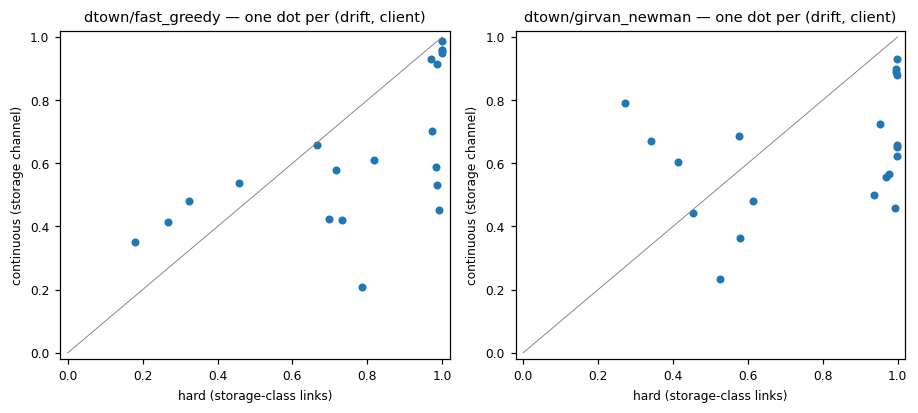

In [12]:
C1, rows = {}, []
for net, meth in PARTS:
    g = LK[(LK["network"] == net) & (LK["districting"] == meth)]
    names = sorted(g["drift"].unique())
    m_ = lambda col: (g.assign(v=g[col].abs()).groupby(["home", "drift"])["v"].mean()
                      .unstack("drift").reindex(index=names, columns=names))
    Dall = m_("gn")
    diag = np.diag(Dall.to_numpy(float))
    C1[(net, meth)] = {ch: m_(col).div(np.where(diag > 0, diag, np.nan), axis=0)
                       for ch, col in (("all", "gn"), ("demand", "gn_dem"), ("storage", "gn_sto"),
                                       ("residual", "gn_res"), ("null", "gn_null"))}
    sdn = T.get("stack_D_native")
    if sdn is not None:
        sdn = sdn[(sdn["network"] == net) & (sdn["districting"] == meth)]
        stack = sdn.pivot_table(index="j", columns="k", values="D").reindex(index=names, columns=names)
        C1[(net, meth)]["stack_native"] = rel(stack)
        for ch in ("all", "demand", "storage"):
            a, b = offdiag(C1[(net, meth)]["stack_native"]), offdiag(C1[(net, meth)][ch])
            ok = np.isfinite(a) & np.isfinite(b)
            rows.append({"network": net, "districting": meth, "channel": ch,
                         "offdiag_mean_R": float(np.nanmean(b)),
                         "stack_native_offdiag_mean_R": float(np.nanmean(a)),
                         "spearman_vs_stack_native": pd.Series(a[ok]).rank().corr(pd.Series(b[ok]).rank())
                         if ok.sum() > 3 else np.nan, "entries": int(ok.sum())})
pd.concat([Mx.rename_axis("j").reset_index().melt(id_vars="j", var_name="k", value_name="R")
           .assign(network=key[0], districting=key[1], channel=ch)
           for key, v in C1.items() for ch, Mx in v.items()],
          ignore_index=True).to_parquet(OUT_DIR / "C1_long.parquet", index=False)
display(Markdown("**C1 — off-diagonal level per channel (relative to diag of the total) and ranking "
                 "agreement with the stack's native dependence**"))
display(pd.DataFrame(rows).round(3))

rows = []
for (net, meth, dr, hm), q in LK[LK["home"] != LK["drift"]].groupby(
        ["network", "districting", "drift", "home"]):
    tot = q["gabs"].sum()
    cd, cs = q["gn_dem"].abs().sum(), q["gn_sto"].abs().sum()
    rows.append({"network": net, "districting": meth, "drift": dr, "client": hm,
                 "hard_storage_share": q.loc[q["storage"], "gabs"].sum() / tot if tot > 0 else np.nan,
                 "continuous_storage_share": cs / (cd + cs) if cd + cs > 0 else np.nan})
C2 = pd.DataFrame(rows)
C2.to_parquet(OUT_DIR / "C2.parquet", index=False)
display(Markdown("**C2 — storage share of each client's off-diagonal response: hard vs continuous**"))
display(C2.set_index(["network", "districting", "drift", "client"]).round(2))
fig, axes = plt.subplots(1, len(PARTS), figsize=(4.2 * len(PARTS), 3.8), squeeze=False)
for ax, (net, meth) in zip(axes[0], PARTS):
    q = C2[(C2["network"] == net) & (C2["districting"] == meth)]
    ax.scatter(q["hard_storage_share"], q["continuous_storage_share"], s=18)
    ax.plot([0, 1], [0, 1], color="0.5", lw=0.6)
    ax.set(xlim=(-0.02, 1.02), ylim=(-0.02, 1.02), xlabel="hard (storage-class links)",
           ylabel="continuous (storage channel)", title=f"{net}/{meth} — one dot per (drift, client)")
fig.tight_layout(); plt.show()

## X — the KY7 attribution anomaly: hub-explained vs residual

Each storage link's standardised level change (S2) is split into the part its best hub element explains —
its init-window regression slope on that element times the element's own settled − init change, in the
same units — and the residual. Cosines between worlds of a partition, over links storage-class in both:

| reading | |
|---|---|
| `hub` ≈ ±1 and `residual` not | storage links move together through the hub; what distinguishes drifts is not the hub |
| `hub` itself not ±1 | the hub elements respond differently to different drifts (multi-hub, or regime changes) |

In [13]:
rows = []
for (net, meth), g in LK.groupby(["network", "districting"]):
    worlds = sorted(g["world"].unique())
    for a, b in combinations(worlds, 2):
        A = g[g["world"] == a].set_index("id")
        B = g[g["world"] == b].set_index("id")
        ids = [i for i in A.index.intersection(B.index) if A.at[i, "storage"] and B.at[i, "storage"]]
        row = {"network": net, "districting": meth, "drift_a": A["drift"].iat[0],
               "drift_b": B["drift"].iat[0], "links": len(ids)}
        for part, col in (("total", "S2_level"), ("hub", "S2_hub"), ("residual", "S2_res")):
            va, vb = A.loc[ids, col].to_numpy(float), B.loc[ids, col].to_numpy(float)
            ok = np.isfinite(va) & np.isfinite(vb)
            den = np.linalg.norm(va[ok]) * np.linalg.norm(vb[ok])
            row[part] = float(va[ok] @ vb[ok] / den) if den > 0 else np.nan
        rows.append(row)
XA = pd.DataFrame(rows)
XA.to_parquet(OUT_DIR / "X_attribution.parquet", index=False)
display(XA.round(2))
display(Markdown("**Share of the level change the hub explains** (median per world over storage links: "
                 "|S2_hub| / (|S2_hub| + |S2_res|))"))
sl = LK[LK["storage"]].assign(hub_share=lambda x: x["S2_hub"].abs() /
                              (x["S2_hub"].abs() + x["S2_res"].abs()))
display(sl.groupby(WKEY)["hub_share"].median().round(3).to_frame())

,network,districting,drift_a,drift_b,links,total,hub,residual
0,dtown,fast_greedy,District_A,District_B,144,-0.17,-0.07,-0.05
1,dtown,fast_greedy,District_A,District_C,142,-0.38,-0.52,-0.00
2,dtown,fast_greedy,District_A,District_E,153,0.08,0.30,-0.07
3,dtown,fast_greedy,District_A,District_D,143,0.07,0.28,-0.07
4,dtown,fast_greedy,District_B,District_C,142,0.46,0.16,0.51
5,dtown,fast_greedy,District_B,District_E,144,-0.16,-0.14,0.08
6,dtown,fast_greedy,District_B,District_D,143,-0.48,-0.10,-0.35
7,dtown,fast_greedy,District_C,District_E,142,-0.37,-0.99,0.06
8,dtown,fast_greedy,District_C,District_D,142,-0.51,-0.63,-0.21
9,dtown,fast_greedy,District_E,District_D,143,0.18,0.66,-0.01


**Share of the level change the hub explains** (median per world over storage links: |S2_hub| / (|S2_hub| + |S2_res|))

hub_share
network districting   drift      world              
dtown   fast_greedy   District_A 0d26d191      0.558
                      District_B 1ca8610b      0.478
                      District_C 57c3c8bf      0.676
                      District_D bac4d730      0.794
                      District_E 8ce38ac4      0.784
        girvan_newman District_A 8190c13b      0.751
                      District_B 7c8f5a98      0.481
                      District_C 4cc1d3b4      0.716
                      District_D 18c49d14      0.618
                      District_E 583ea08f      0.657

## V — visualisations

1. **Network maps** per partition: links coloured by set (majority over worlds); a second map by class
   stability; a third by the hub element storage links observe. Tanks ■, reservoirs ◆, pumps ▲.
2. **S1 timelines** per world: links (rows, sorted by set then home) × months, colour = S1 ratio (log);
   vertical lines at the first switch and the settled window.
3. **Example series** per set (init vs settled, 14 days), with the home district's demand.
4. **Matrices**: stack $R$, empirical $R$ (all / demand / dedup), noise floor, observational (raw / anom,
   demand vs storage).

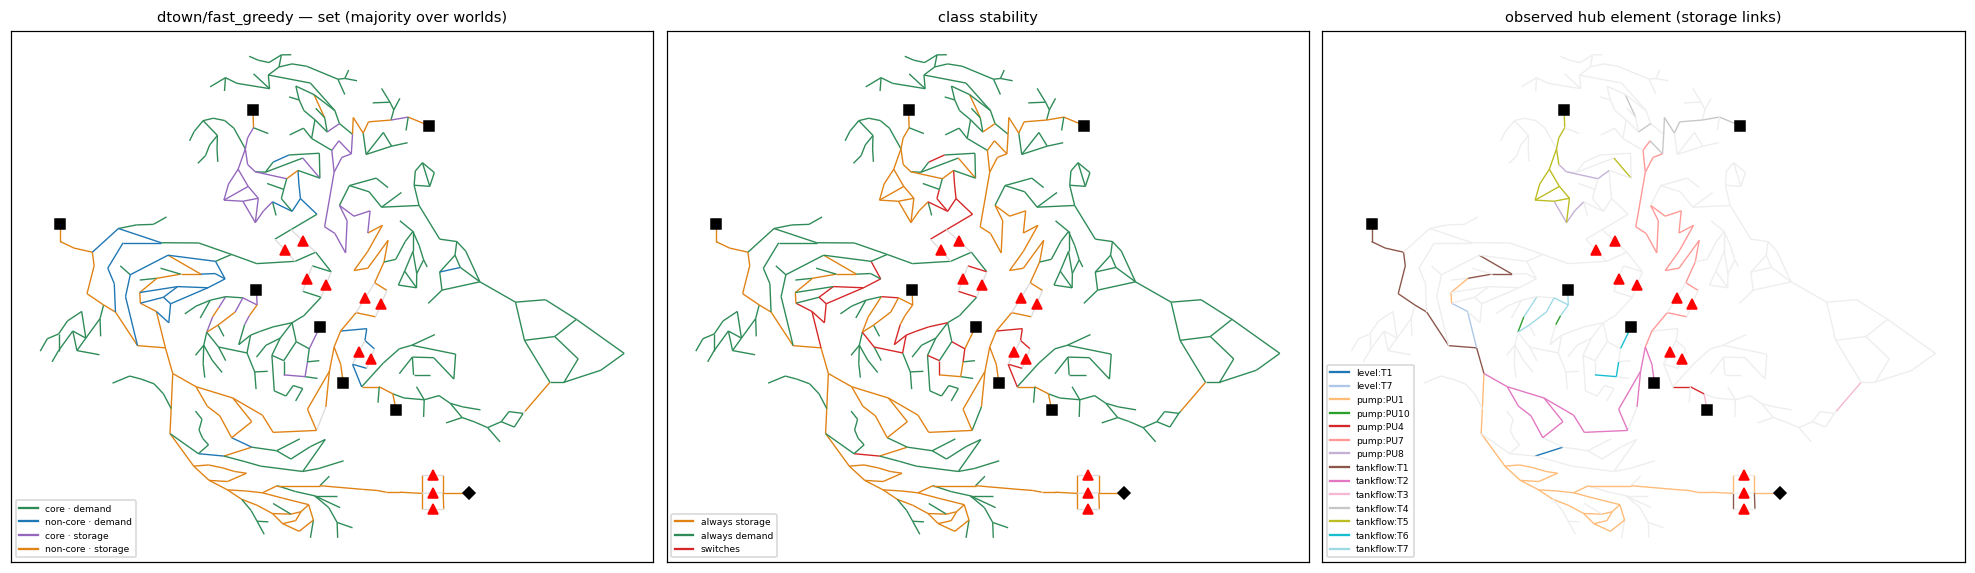

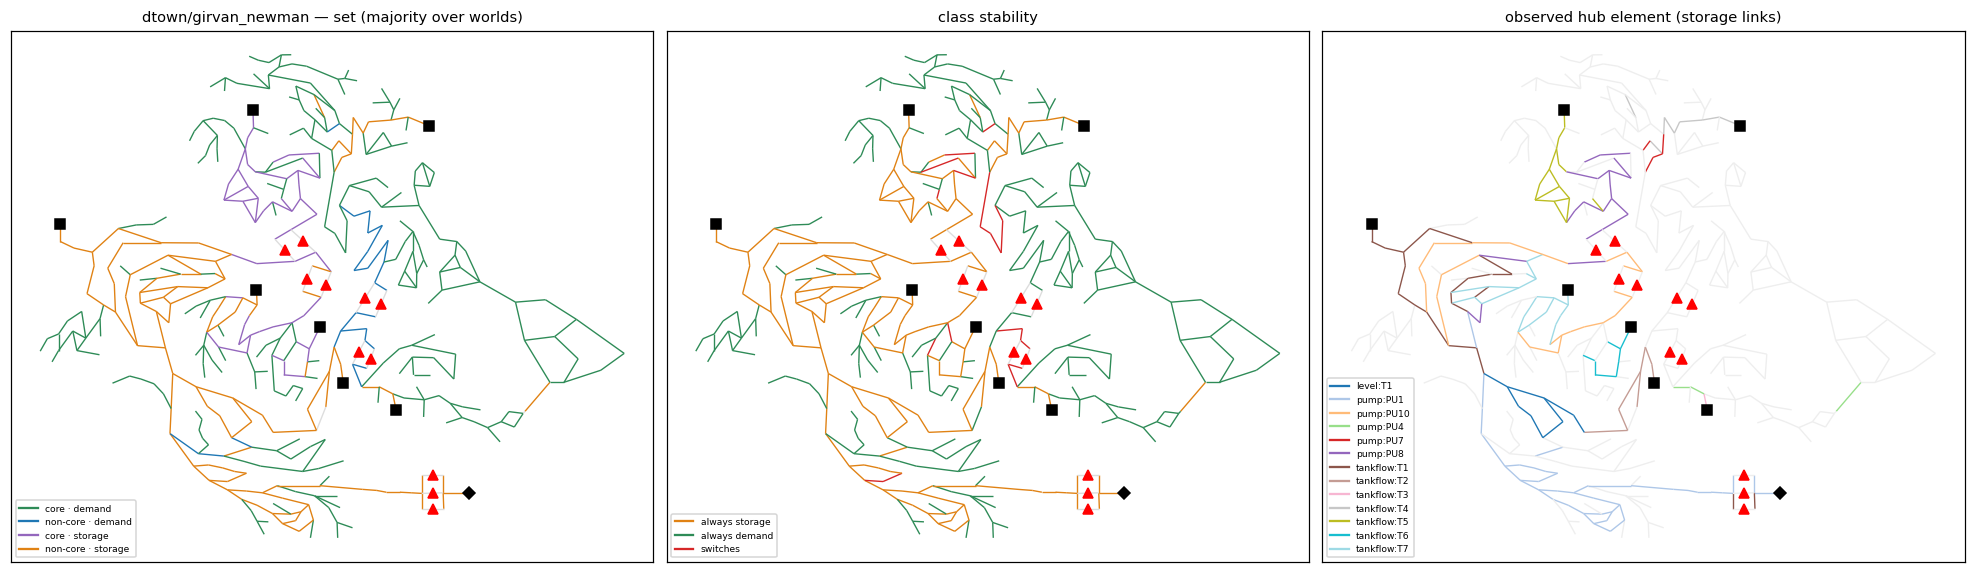

In [14]:
def draw_network(ax, wn, colour_of, title, legend=None):
    segs, cols = [], []
    for ln in wn.link_name_list:
        l = wn.get_link(ln)
        a, b = wn.get_node(l.start_node_name).coordinates, wn.get_node(l.end_node_name).coordinates
        segs.append([a, b]); cols.append(colour_of(ln))
    ax.add_collection(LineCollection(segs, colors=cols, linewidths=0.9))
    for t in wn.tank_name_list:
        x, y = wn.get_node(t).coordinates; ax.plot(x, y, "s", ms=6, color="k")
    for rv in wn.reservoir_name_list:
        x, y = wn.get_node(rv).coordinates; ax.plot(x, y, "D", ms=6, color="k")
    for p in wn.pump_name_list:
        l = wn.get_link(p)
        a, b = wn.get_node(l.start_node_name).coordinates, wn.get_node(l.end_node_name).coordinates
        ax.plot((a[0] + b[0]) / 2, (a[1] + b[1]) / 2, "^", ms=6, color="r")
    ax.autoscale(); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title)
    if legend:
        ax.legend(handles=legend, fontsize=6, loc="lower left")


for net, meth in PARTS:
    wn = NETS[net]
    g = LK[(LK["network"] == net) & (LK["districting"] == meth)]
    maj = g.groupby("element").agg(set=("set", lambda s: s.mode().iat[0]),
                                   share=("storage", "mean"),
                                   hub=("S3_hub", lambda s: s.mode().iat[0] if s.notna().any() else None))
    maj.index = maj.index.astype(str)
    hubs = sorted(maj.loc[maj["share"] >= 0.5, "hub"].dropna().unique())
    hub_col = {h_: tuple(c_) for h_, c_ in zip(hubs, plt.cm.tab20(np.linspace(0, 1, max(len(hubs), 1))))}
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    draw_network(axes[0], wn, lambda ln: SET_COLOUR.get(maj["set"].get(ln), "#dddddd"),
                 f"{net}/{meth} — set (majority over worlds)",
                 [Line2D([], [], color=c, label=s) for s, c in SET_COLOUR.items()])
    stab = lambda ln: ("#dddddd" if ln not in maj.index else
                       "#e08214" if maj.at[ln, "share"] == 1 else
                       "#2e8b57" if maj.at[ln, "share"] == 0 else "#d62728")
    draw_network(axes[1], wn, stab, "class stability",
                 [Line2D([], [], color=c, label=s) for s, c in
                  (("always storage", "#e08214"), ("always demand", "#2e8b57"), ("switches", "#d62728"))])
    draw_network(axes[2], wn, lambda ln: hub_col.get(maj["hub"].get(ln), "#eeeeee")
                 if ln in maj.index and maj.at[ln, "share"] >= 0.5 else "#eeeeee",
                 "observed hub element (storage links)",
                 [Line2D([], [], color=c, label=h) for h, c in hub_col.items()])
    fig.tight_layout(); plt.show()

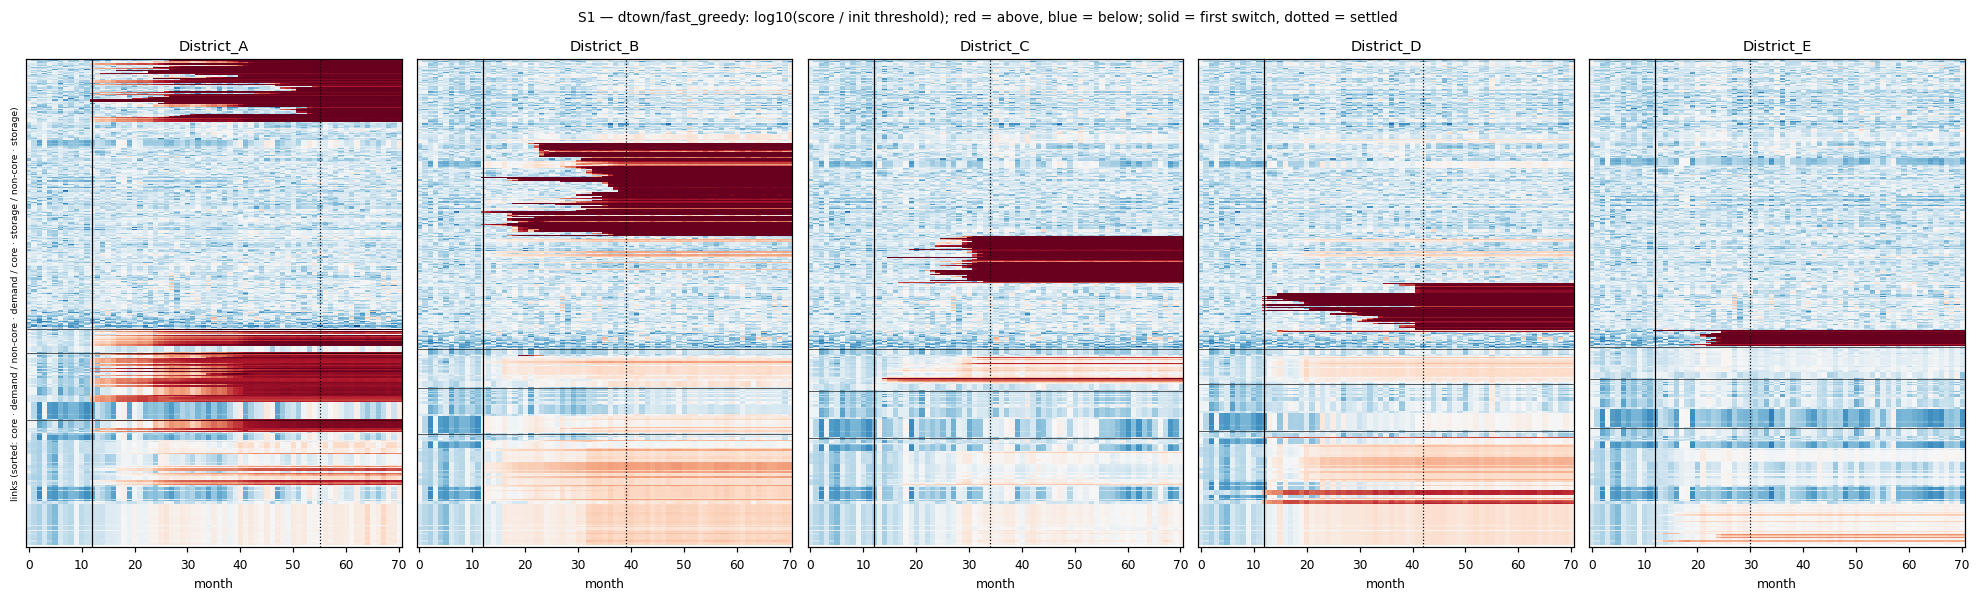

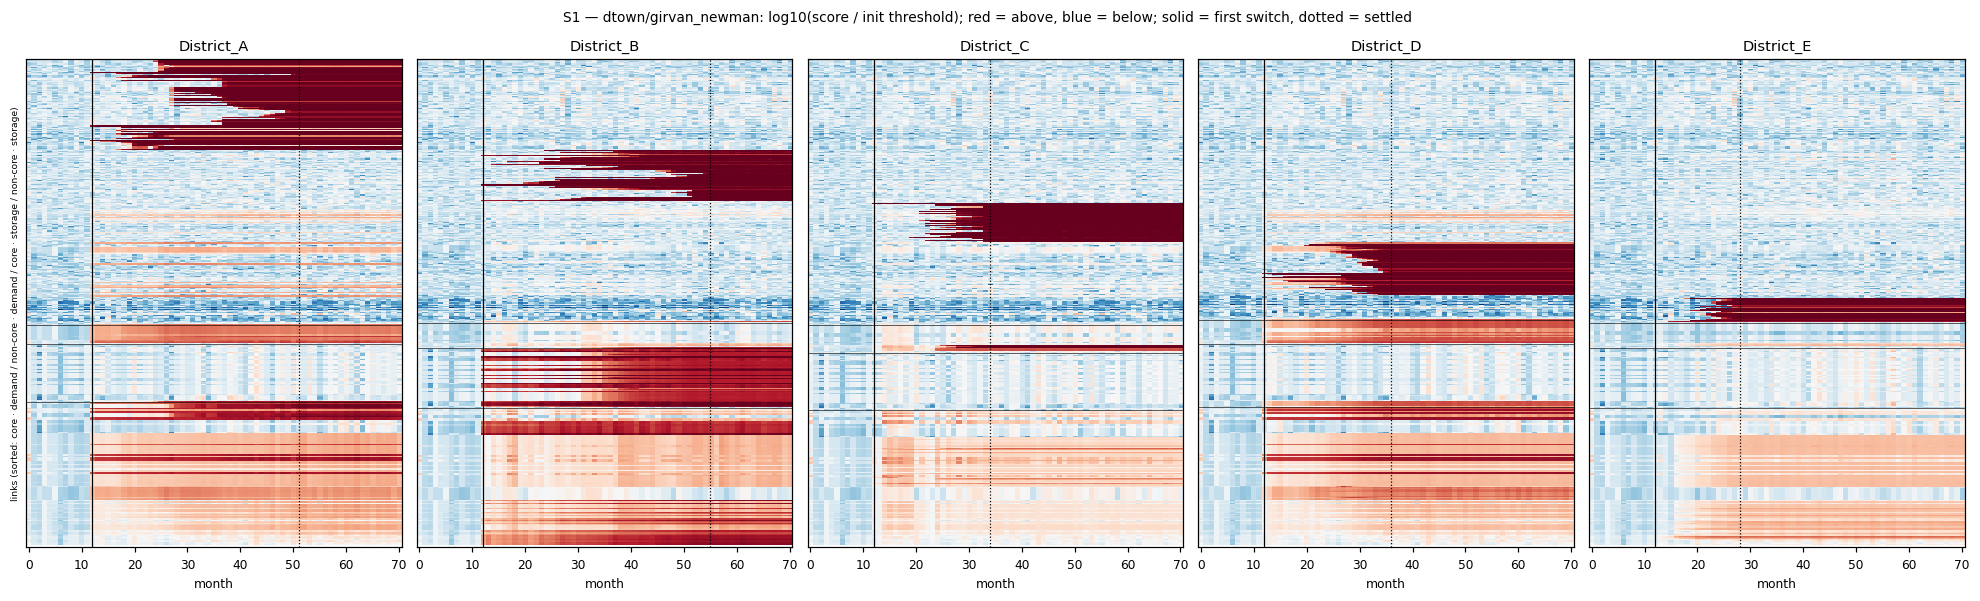

In [15]:
ML = T["monthly_links"].merge(LK[WKEY + ["id", "set", "home"]], on=WKEY + ["id"], how="left")
for net, meth in PARTS:
    worlds = LK[(LK["network"] == net) & (LK["districting"] == meth)][WKEY].drop_duplicates()
    fig, axes = plt.subplots(1, len(worlds), figsize=(3.6 * len(worlds), 5.5), squeeze=False)
    for ax, (_, wr) in zip(axes[0], worlds.iterrows()):
        q = ML[(ML["world"] == wr["world"])]
        order = (LK[LK["world"] == wr["world"]].assign(si=lambda x: x["set"].map(
                 {s: i for i, s in enumerate(SETS)}).fillna(9)).sort_values(["si", "home"])["id"])
        piv = q.pivot_table(index="id", columns="month", values="ratio").reindex(order)
        ax.imshow(np.log10(piv.clip(lower=1e-2).to_numpy()), aspect="auto", cmap="RdBu_r",
                  vmin=-1, vmax=1, interpolation="nearest")
        wrow = T["worlds"][T["worlds"]["world"] == wr["world"]].iloc[0]
        ax.axvline(wrow["first_month"], color="k", lw=0.8)
        ax.axvline(wrow["settled_month"], color="k", lw=0.8, ls=":")
        sizes = LK[LK["world"] == wr["world"]]["set"].value_counts().reindex(SETS).fillna(0).cumsum()
        for y in sizes.to_numpy()[:-1]:
            ax.axhline(y, color="k", lw=0.4)
        ax.set(title=f"{wr['drift']}", xlabel="month", yticks=[])
    axes[0][0].set_ylabel("links (sorted: " + " / ".join(SETS) + ")", fontsize=6)
    fig.suptitle(f"S1 — {net}/{meth}: log10(score / init threshold); red = above, blue = below; "
                 "solid = first switch, dotted = settled", fontsize=9)
    fig.tight_layout(); plt.show()

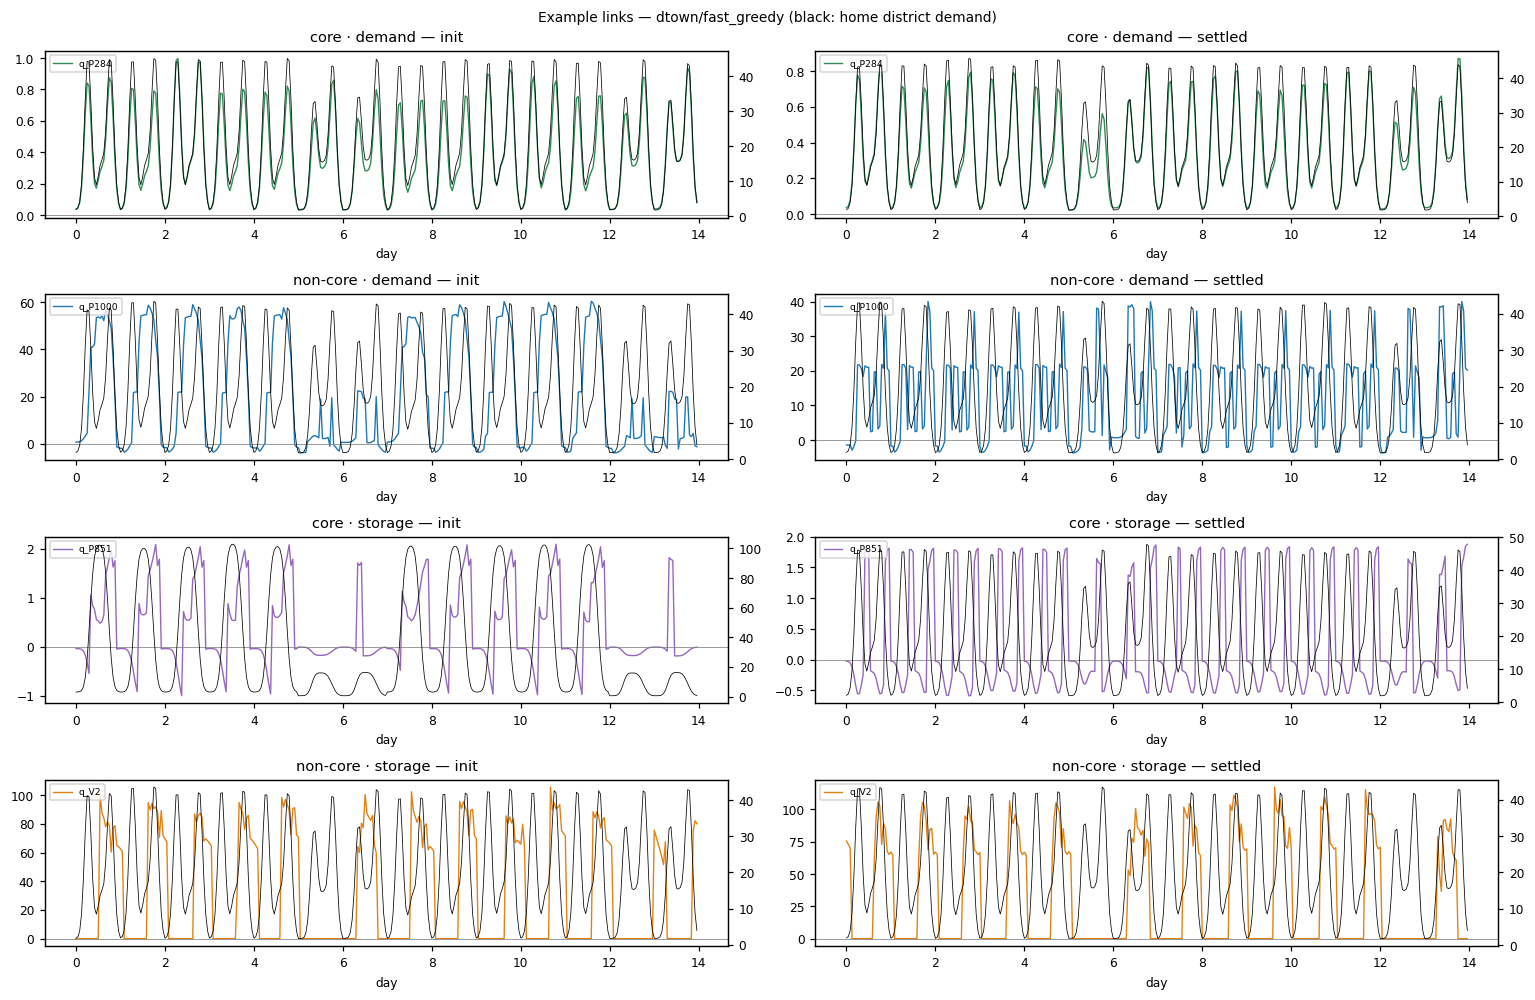

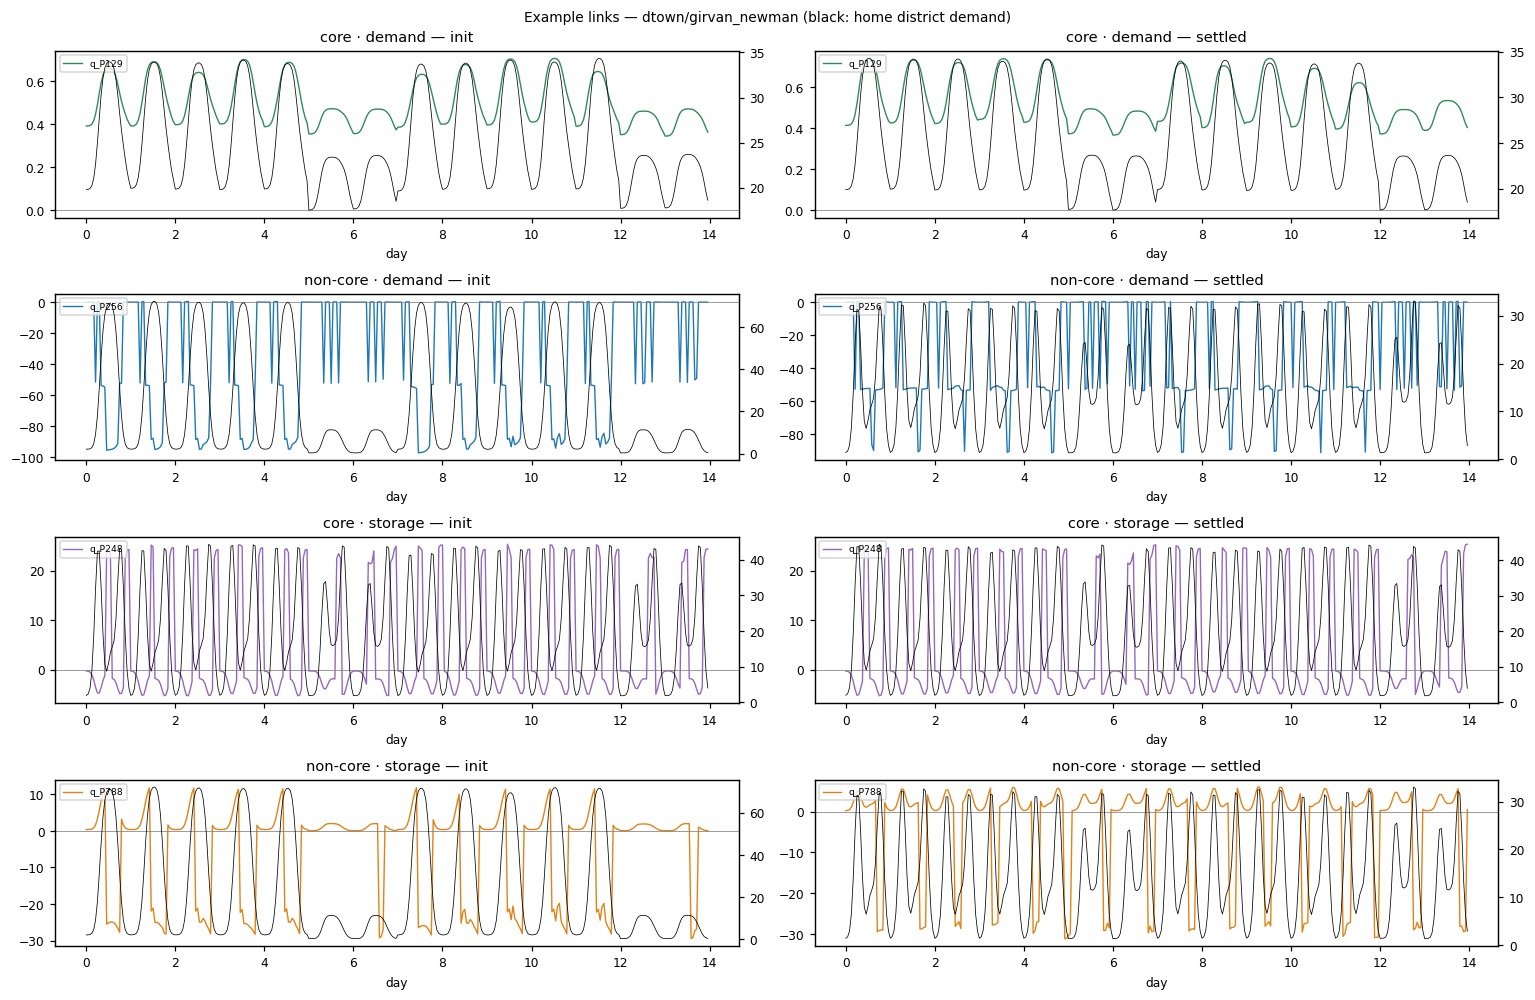

In [16]:
EX = T["examples"]
for (net, meth), g in EX.groupby(["network", "districting"]):
    sets = [s for s in SETS if s in g["set"].unique()]
    fig, axes = plt.subplots(len(sets), 2, figsize=(14, 2.3 * len(sets)), squeeze=False)
    for i, s in enumerate(sets):
        for j, wname in enumerate(("init", "settled")):
            q = g[(g["set"] == s) & (g["window"] == wname)]
            ax = axes[i][j]
            ax.plot(q["hour"] / 24, q["flow"], color=SET_COLOUR[s], lw=0.9, label=q["id"].iat[0])
            ax2 = ax.twinx(); ax2.plot(q["hour"] / 24, q["home_demand"], color="k", lw=0.5)
            ax.axhline(0, color="0.5", lw=0.5)
            ax.set(title=f"{s} — {wname}", xlabel="day"); ax.legend(fontsize=6, loc="upper left")
    fig.suptitle(f"Example links — {net}/{meth} (black: home district demand)", fontsize=9)
    fig.tight_layout(); plt.show()

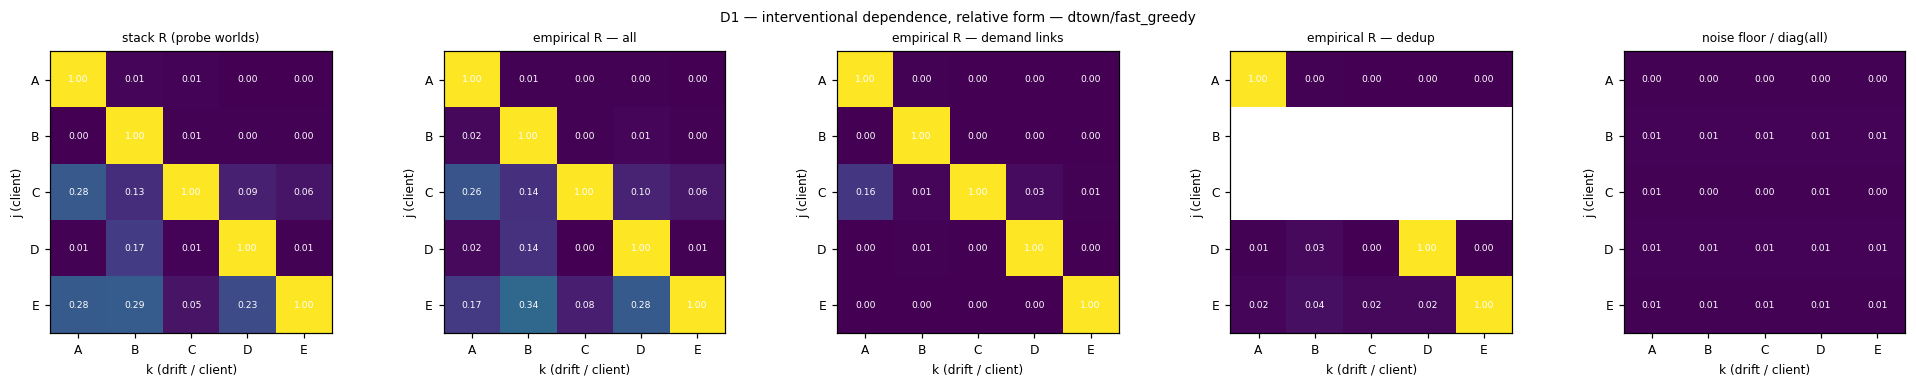

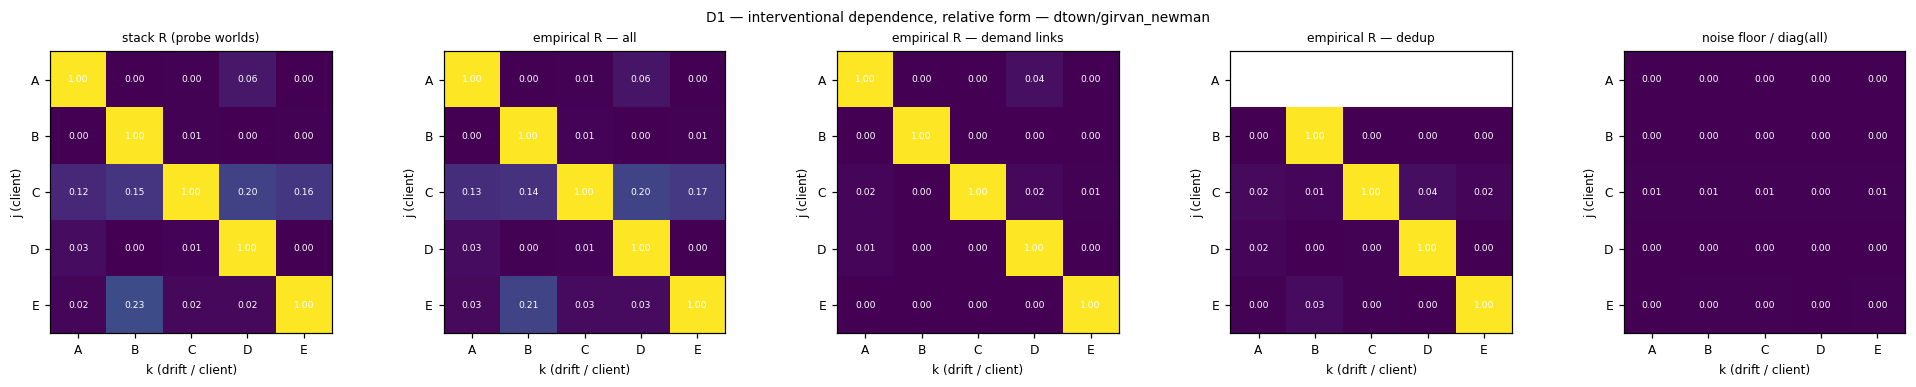

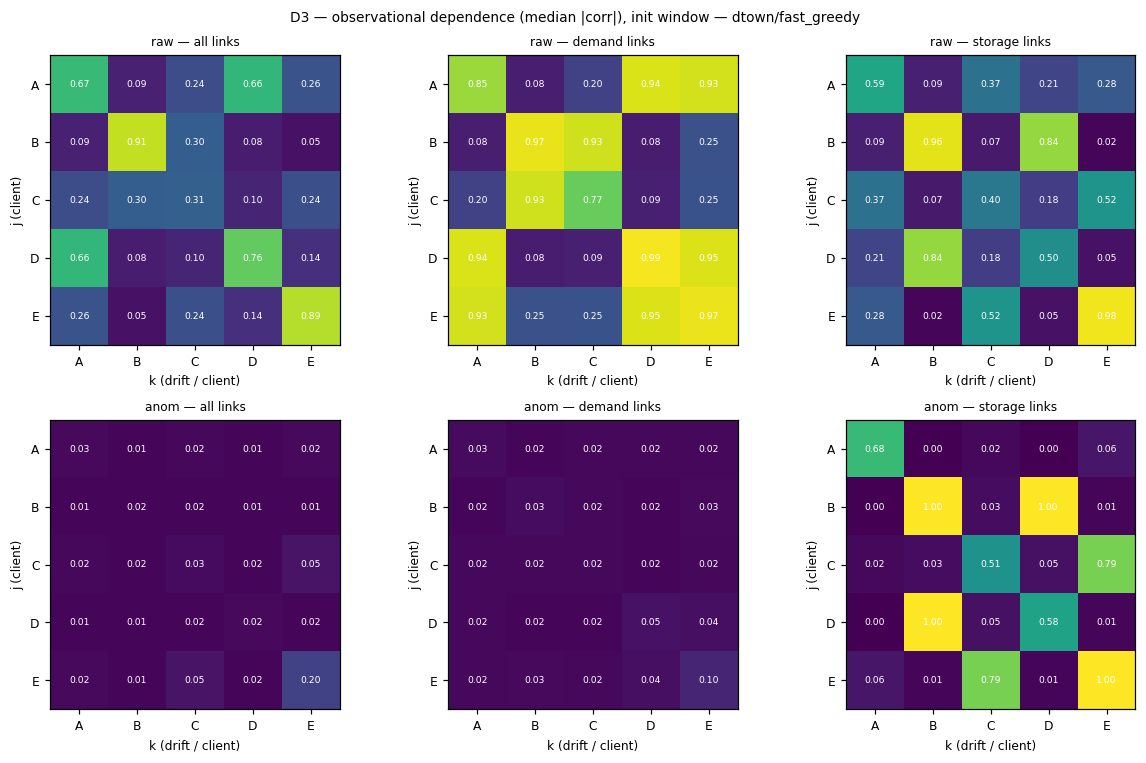

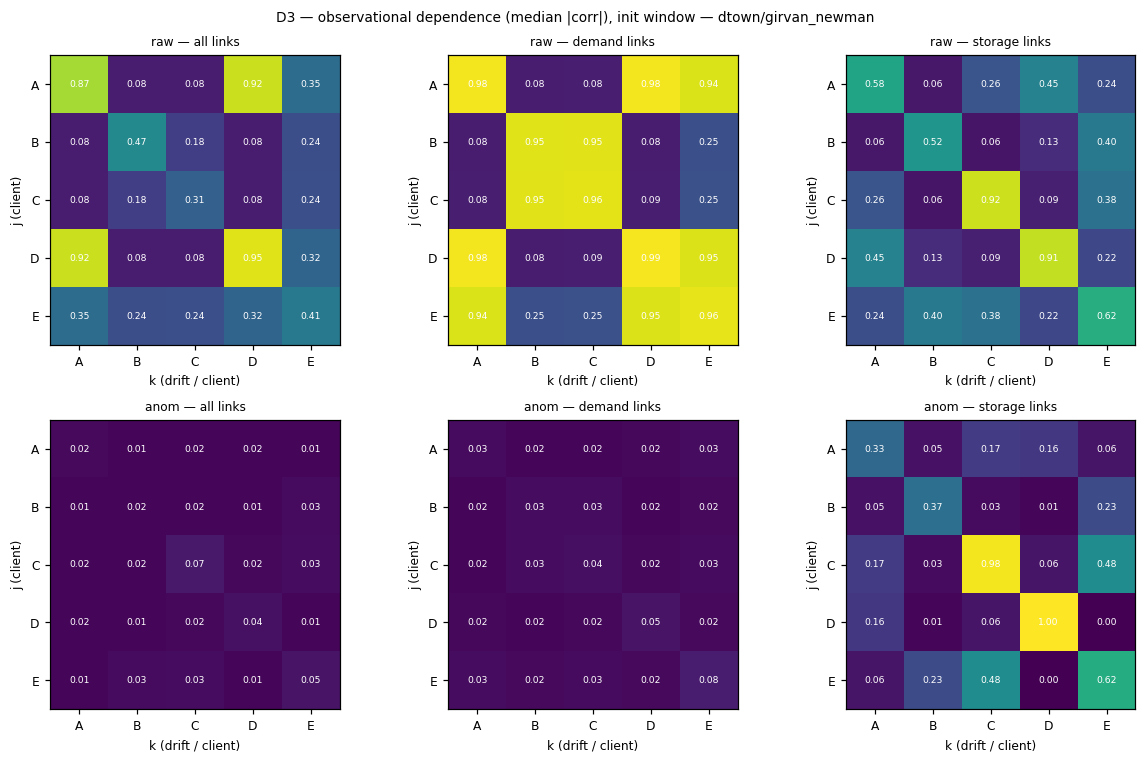

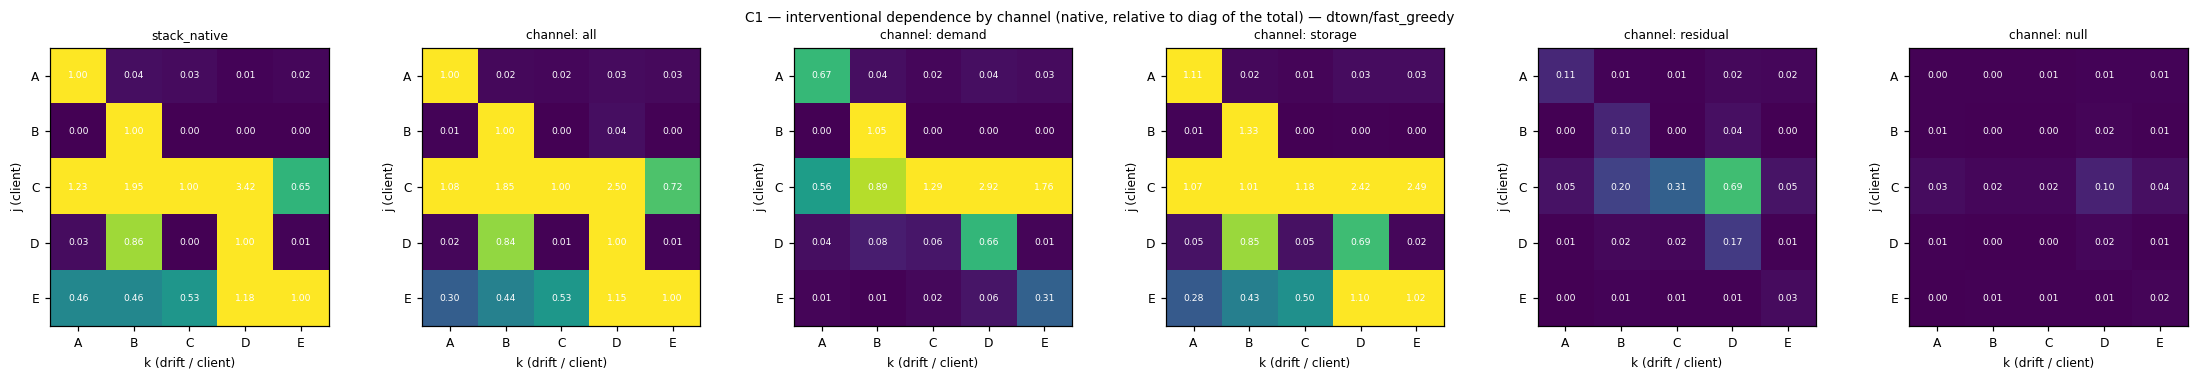

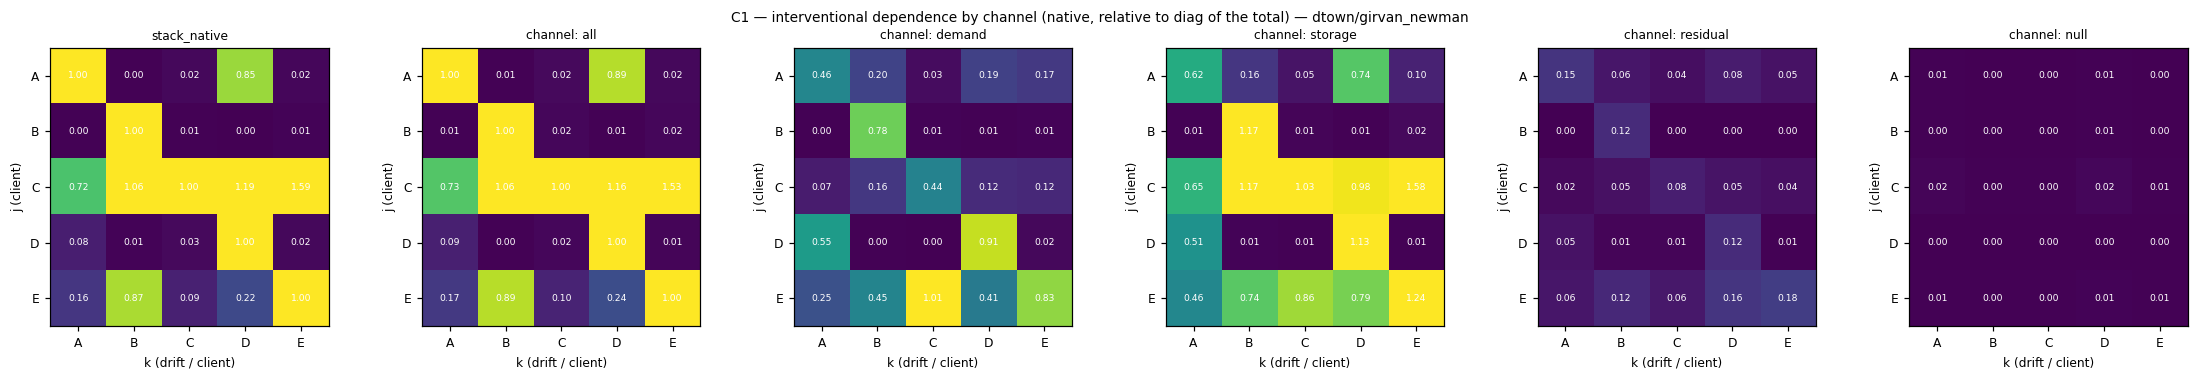

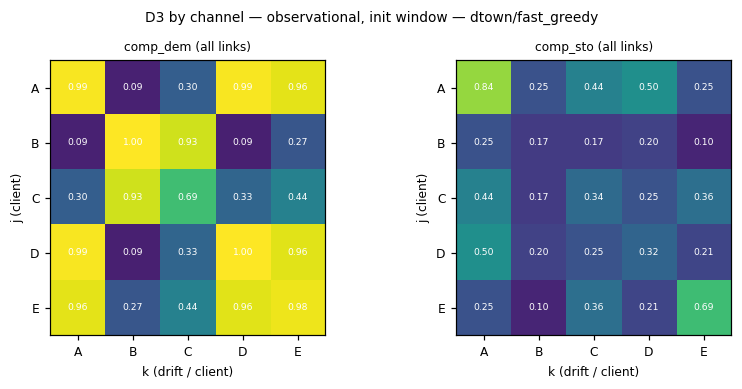

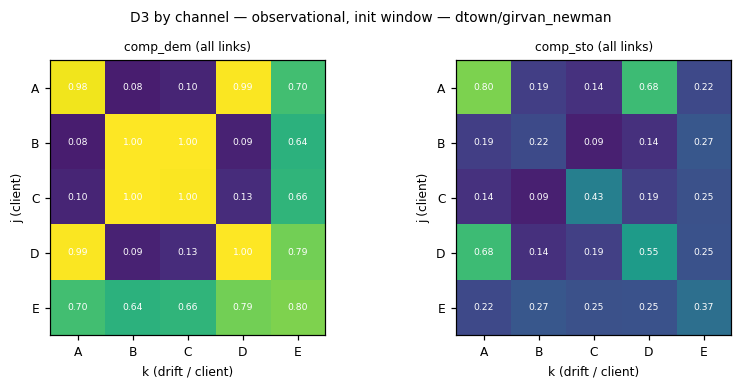

In [17]:
def heat(ax, Mx, title, vmax=None):
    A = Mx.to_numpy(float)
    im = ax.imshow(A, cmap="viridis", vmin=0, vmax=vmax if vmax else np.nanmax(A))
    ax.set_xticks(range(A.shape[1])); ax.set_xticklabels([c[-1] for c in Mx.columns])
    ax.set_yticks(range(A.shape[0])); ax.set_yticklabels([str(c)[-1] if str(c) != "hub" else "hub"
                                                           for c in Mx.index])
    for (y, x), v in np.ndenumerate(A):
        if np.isfinite(v):
            ax.text(x, y, f"{v:.2f}", ha="center", va="center", fontsize=6, color="w")
    ax.set_title(title, fontsize=8); ax.set_xlabel("k (drift / client)"); ax.set_ylabel("j (client)")


for key, v in D1.items():
    sd_ = T["stack_D"]
    sd_ = sd_[(sd_["network"] == key[0]) & (sd_["districting"] == key[1])]
    stack = sd_.pivot_table(index="j", columns="k", values="D").reindex(
        index=v["all"].index, columns=v["all"].columns)
    panels = [("stack R (probe worlds)", rel(stack)), ("empirical R — all", rel(v["all"])),
              ("empirical R — demand links", rel(v["demand"])), ("empirical R — dedup", rel(v["dedup"])),
              ("noise floor / diag(all)",
               v["null"].div(np.diag(v["all"].to_numpy(float)), axis=0))]
    fig, axes = plt.subplots(1, len(panels), figsize=(3.6 * len(panels), 3.4))
    for ax, (t, Mx) in zip(axes, panels):
        heat(ax, Mx, t, vmax=1.0)
    fig.suptitle(f"D1 — interventional dependence, relative form — {key[0]}/{key[1]}", fontsize=9)
    fig.tight_layout(); plt.show()

for (net, meth), g in OBS.groupby(["network", "districting"]):
    fig, axes = plt.subplots(2, 3, figsize=(11, 7))
    for i, sig in enumerate(("raw", "anom")):
        for j, sub in enumerate(("all", "demand", "storage")):
            q = g[(g["signal"] == sig) & (g["subset"] == sub)]
            heat(axes[i][j], q.pivot_table(index="j", columns="k", values="O"),
                 f"{sig} — {sub} links", vmax=1.0)
    fig.suptitle(f"D3 — observational dependence (median |corr|), init window — {net}/{meth}", fontsize=9)
    fig.tight_layout(); plt.show()

for key, v in C1.items():
    panels = [(ch, v[ch]) for ch in ("stack_native", "all", "demand", "storage", "residual", "null") if ch in v]
    fig, axes = plt.subplots(1, len(panels), figsize=(3.4 * len(panels), 3.3))
    for ax, (t, Mx) in zip(np.atleast_1d(axes), panels):
        heat(ax, Mx, t if t == "stack_native" else f"channel: {t}", vmax=1.0)
    fig.suptitle(f"C1 — interventional dependence by channel (native, relative to diag of the total) "
                 f"— {key[0]}/{key[1]}", fontsize=9)
    fig.tight_layout(); plt.show()

for (net, meth), g in OBS[OBS["signal"].isin(["comp_dem", "comp_sto"])].groupby(["network", "districting"]):
    fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.5))
    for ax, sig in zip(axes, ("comp_dem", "comp_sto")):
        q = g[g["signal"] == sig]
        heat(ax, q.pivot_table(index="j", columns="k", values="O"), f"{sig} (all links)", vmax=1.0)
    fig.suptitle(f"D3 by channel — observational, init window — {net}/{meth}", fontsize=9)
    fig.tight_layout(); plt.show()